In [ ]:
# ============================================================
# TFM – Análisis Exploratorio de Datos (EDA)
# Dataset YOLO de Expresiones Faciales
# ============================================================
# Antes de ejecutar este notebook:
#   Runtime → Change runtime type → GPU (T4 / A100) + High-RAM
# ============================================================

In [ ]:
# ============================================================
# CELDA 1 – Montar Drive y verificar GPU / RAM disponible
# ============================================================
import subprocess, sys, os

# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# 2. Verificar GPU
print("=" * 55)
print("🖥️  VERIFICACIÓN DE HARDWARE")
print("=" * 55)

try:
    gpu_info = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,memory.free,utilization.gpu',
         '--format=csv,noheader,nounits'],
        capture_output=True, text=True, timeout=10
    )
    if gpu_info.returncode == 0 and gpu_info.stdout.strip():
        for line in gpu_info.stdout.strip().split('\n'):
            parts = [p.strip() for p in line.split(',')]
            print(f"  ✅ GPU    : {parts[0]}")
            print(f"  📦 VRAM   : {int(parts[1]):,} MB totales  |  {int(parts[2]):,} MB libres")
            print(f"  ⚙️  Uso GPU: {parts[3]}%")
    else:
        print("  ⚠️  No se detectó GPU. Ve a Runtime → Change runtime type → GPU.")
except Exception as e:
    print(f"  ⚠️  Error al consultar GPU: {e}")

# 3. Verificar RAM del sistema
try:
    ram_info = subprocess.run(['cat', '/proc/meminfo'], capture_output=True, text=True)
    lines = ram_info.stdout.split('\n')
    mem_total_kb = int([l for l in lines if l.startswith('MemTotal')][0].split()[1])
    mem_avail_kb = int([l for l in lines if l.startswith('MemAvailable')][0].split()[1])
    print(f"  💾 RAM    : {mem_total_kb/1024**2:.1f} GB totales  |  {mem_avail_kb/1024**2:.1f} GB disponibles")
    if mem_total_kb / 1024**2 >= 50:
        print("  ✅ High-RAM activo (≥50 GB)")
    else:
        print("  ⚠️  RAM estándar (~12 GB). Para High-RAM ve a Runtime → Change runtime type.")
except Exception as e:
    print(f"  ⚠️  Error al leer RAM: {e}")

# 4. Verificar versión de Python y CUDA
import torch
print(f"  🐍 Python : {sys.version.split()[0]}")
if torch.cuda.is_available():
    print(f"  🔥 CUDA   : {torch.version.cuda}  |  PyTorch {torch.__version__}")
    print(f"  🎯 Device : {torch.cuda.get_device_name(0)}")
else:
    print("  ⚠️  PyTorch no detecta CUDA.")
print("=" * 55)

Mounted at /content/drive
🖥️  VERIFICACIÓN DE HARDWARE
  ✅ GPU    : Tesla T4
  📦 VRAM   : 15,360 MB totales  |  14,913 MB libres
  ⚙️  Uso GPU: 0%
  💾 RAM    : 51.0 GB totales  |  49.3 GB disponibles
  ✅ High-RAM activo (≥50 GB)
  🐍 Python : 3.12.13
  🔥 CUDA   : 12.8  |  PyTorch 2.11.0+cu128
  🎯 Device : Tesla T4


# 📦 Sección 2 – Importación de Librerías y Configuración de Rutas

In [ ]:
# ============================================================
# CELDA 2 – Librerías, rutas del dataset YOLO y data.yaml
# ============================================================
import os, time, warnings, yaml
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
sns.set_style("darkgrid")

# ── Rutas base ────────────────────────────────────────────────
BASE  = Path("/content/drive/MyDrive/TFM/EXPRESIONES")
YOLO  = BASE / "YOLO_EXPRESIONES_UNIFIED"

SPLITS   = ["train", "val", "test"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── Nombres de clases por defecto (orden = class_id en los .txt) ──
CLASES_DEFAULT = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# ── 1. Intentar leer data.yaml ────────────────────────────────
YAML_PATH   = YOLO / "data.yaml"
CLASS_NAMES = None

if YAML_PATH.exists():
    with open(YAML_PATH, 'r') as f:
        ydata = yaml.safe_load(f)
    CLASS_NAMES = ydata.get('names', None)
    print(f"  ✅ data.yaml encontrado y leído.")
    print(f"     Clases : {CLASS_NAMES}")
else:
    CLASS_NAMES = CLASES_DEFAULT
    print(f"  ⚠️  data.yaml no encontrado. Usando clases por defecto: {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)

# ── 2. Crear data.yaml si no existe (necesario para entrenar YOLO) ──
if not YAML_PATH.exists():
    data_yaml_content = {
        'path' : str(YOLO),
        'train': 'images/train',
        'val'  : 'images/val',
        'test' : 'images/test',
        'nc'   : NUM_CLASSES,
        'names': CLASS_NAMES,
    }
    YOLO.mkdir(parents=True, exist_ok=True)
    with open(YAML_PATH, 'w', encoding='utf-8') as f:
        yaml.dump(data_yaml_content, f,
                  default_flow_style=False,
                  allow_unicode=True,
                  sort_keys=False)
    print(f"  ✅ data.yaml creado automáticamente en:")
    print(f"     {YAML_PATH}")
    print(f"     → Listo para la fase de entrenamiento YOLO.")
else:
    print(f"  ✅ data.yaml ya existía, no se sobreescribió.")

# ── 3. Verificar contenido del data.yaml ──────────────────────
print("\n  📄 Contenido actual de data.yaml:")
with open(YAML_PATH, 'r') as f:
    contenido = yaml.safe_load(f)
for k, v in contenido.items():
    print(f"     {k}: {v}")

# ── 4. Resumen de rutas ───────────────────────────────────────
print(f"\n  📊 Número de clases : {NUM_CLASSES}")
print(f"  📁 Ruta YOLO        : {YOLO}")
print(f"  📁 Existe?          : {YOLO.exists()}")
for split in SPLITS:
    img_ok = (YOLO / "images" / split).exists()
    lbl_ok = (YOLO / "labels" / split).exists()
    print(f"  📂 {split:<6} → images: {'✅' if img_ok else '❌'}  labels: {'✅' if lbl_ok else '❌'}")

  ✅ data.yaml encontrado y leído.
     Clases : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  ✅ data.yaml ya existía, no se sobreescribió.

  📄 Contenido actual de data.yaml:
     path: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
     train: images/train
     val: images/val
     test: images/test
     nc: 7
     names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

  📊 Número de clases : 7
  📁 Ruta YOLO        : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
  📁 Existe?          : True
  📂 train  → images: ✅  labels: ✅
  📂 val    → images: ✅  labels: ✅
  📂 test   → images: ✅  labels: ✅


# 📂 Sección 3 – Conteo de Archivos por Split

📊  CONTEO DE ARCHIVOS POR SPLIT
  TRAIN  │ ✅ Imágenes: 22,561  │ ✅ Labels: 22,561
  VAL    │ ✅ Imágenes:  4,685  │ ✅ Labels:  4,685
  TEST   │ ✅ Imágenes:  5,353  │ ✅ Labels:  5,353
  TOTAL  │    Imágenes: 32,599  │    Labels: 32,599


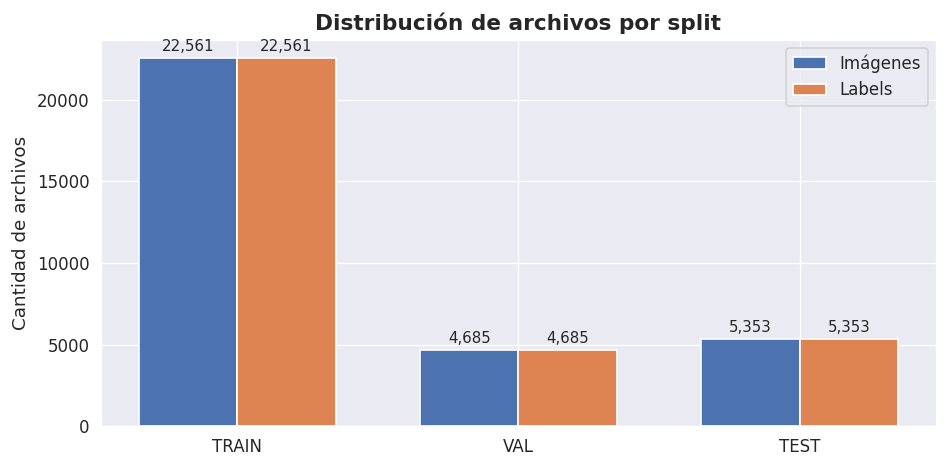

  📈 Gráfica guardada en /content/eda_conteo_splits.png


In [ ]:
# ============================================================
# CELDA 3 – Conteo de imágenes y labels por split
# ============================================================

def contar_archivos(directorio, tipo="cualquiera"):
    """Cuenta archivos en un directorio filtrando por tipo."""
    if not directorio.exists():
        return 0, f"Carpeta no encontrada: {directorio}"
    try:
        count = 0
        for entry in directorio.iterdir():
            if not entry.is_file():
                continue
            if tipo == "imagen":
                if entry.suffix.lower() in IMG_EXTS:
                    count += 1
            elif tipo == "label":
                if entry.suffix.lower() == ".txt":
                    count += 1
            else:
                count += 1
        return count, None
    except OSError as e:
        return 0, f"Error I/O: {e}"

print("=" * 60)
print("📊  CONTEO DE ARCHIVOS POR SPLIT")
print("=" * 60)

resumen_conteo = {}
for split in SPLITS:
    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split
    n_img, e_img = contar_archivos(img_dir, "imagen")
    n_lbl, e_lbl = contar_archivos(lbl_dir, "label")
    resumen_conteo[split] = {"imagenes": n_img, "labels": n_lbl}
    estado_img = "✅" if not e_img else "❌"
    estado_lbl = "✅" if not e_lbl else "❌"
    print(f"  {split.upper():<6} │ {estado_img} Imágenes: {n_img:>6,}  │ {estado_lbl} Labels: {n_lbl:>6,}")

print("=" * 60)
total_img = sum(v["imagenes"] for v in resumen_conteo.values())
total_lbl = sum(v["labels"]   for v in resumen_conteo.values())
print(f"  {'TOTAL':<6} │ {'':2} Imágenes: {total_img:>6,}  │ {'':2} Labels: {total_lbl:>6,}")
print("=" * 60)

# ── Gráfica de barras ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x  = np.arange(len(SPLITS))
w  = 0.35
b1 = ax.bar(x - w/2, [resumen_conteo[s]["imagenes"] for s in SPLITS], w, label="Imágenes", color="#4C72B0")
b2 = ax.bar(x + w/2, [resumen_conteo[s]["labels"]   for s in SPLITS], w, label="Labels",   color="#DD8452")
ax.set_title("Distribución de archivos por split", fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_ylabel("Cantidad de archivos"); ax.legend()
for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():,}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/eda_conteo_splits.png', dpi=120, bbox_inches='tight')
plt.show()
print("  📈 Gráfica guardada en /content/eda_conteo_splits.png")

# 📊 Sección 4 – Distribución de Clases por Split

📊  Leyendo labels de todos los splits…


Leyendo labels train:   0%|          | 0/22561 [00:00<?, ?it/s]

  TRAIN : 4,282 anotaciones


Leyendo labels val:   0%|          | 0/4685 [00:00<?, ?it/s]

  VAL   : 1,599 anotaciones


Leyendo labels test:   0%|          | 0/5353 [00:00<?, ?it/s]

  TEST  : 1,866 anotaciones

📋 Tabla de distribución de clases:
          train  val  test  TOTAL
angry      1047  390   492   1929
disgust     244  102   104    450
fear        453  176   173    802
happy       471  170   204    845
neutral      73   27    32    132
sad         313  107   137    557
surprise    897  323   367   1587


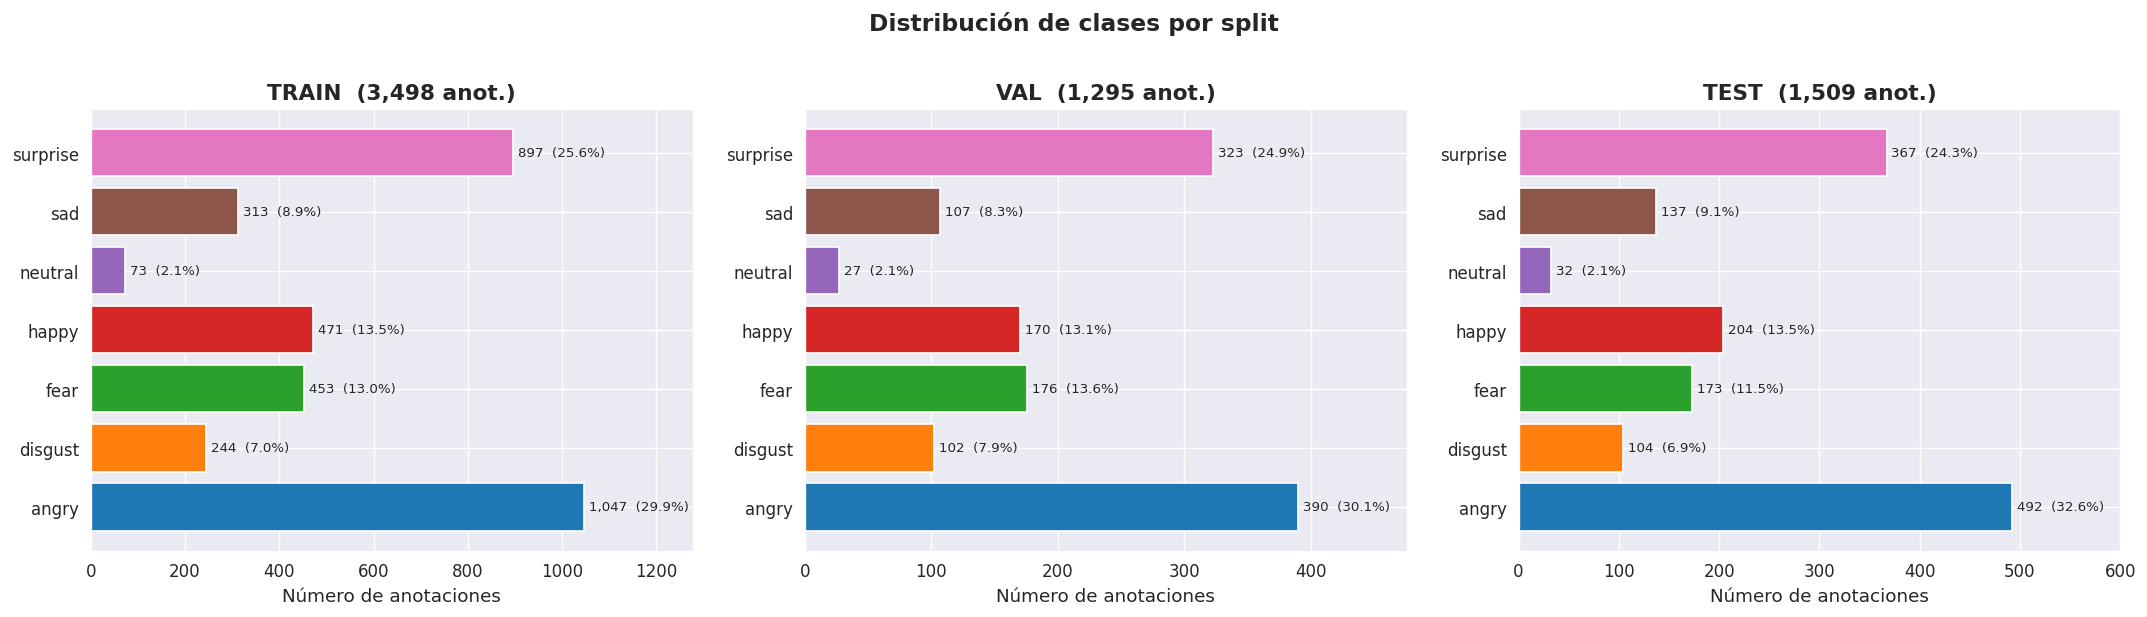


⚠️  Análisis de desbalanceo (split TRAIN):
    angry       :  29.9%
    disgust     :   7.0%
    fear        :  13.0%
    happy       :  13.5%
    neutral     :   2.1% ← posible desbalanceo
    sad         :   8.9%
    surprise    :  25.6%


In [ ]:
# ============================================================
# CELDA 4 – Distribución de clases en train / val / test
# ============================================================

def leer_labels_split(split):
    """Lee todos los .txt del split y devuelve lista de class_ids."""
    lbl_dir = YOLO / "labels" / split
    class_ids = []
    if not lbl_dir.exists():
        print(f"  ❌ No existe: {lbl_dir}")
        return class_ids
    for f in tqdm(list(lbl_dir.iterdir()), desc=f"Leyendo labels {split}", leave=False):
        if f.suffix.lower() != ".txt":
            continue
        try:
            with open(f, 'r') as fh:
                for line in fh:
                    line = line.strip()
                    if line:
                        class_ids.append(int(line.split()[0]))
        except Exception:
            pass
    return class_ids

print("📊  Leyendo labels de todos los splits…")
dist_clases = {}
for split in SPLITS:
    ids = leer_labels_split(split)
    dist_clases[split] = Counter(ids)
    total = sum(dist_clases[split].values())
    print(f"  {split.upper():<6}: {total:,} anotaciones")

# ── DataFrame resumen ─────────────────────────────────────────
df_dist = pd.DataFrame(
    {split: [dist_clases[split].get(i, 0) for i in range(NUM_CLASSES)] for split in SPLITS},
    index=CLASS_NAMES
)
df_dist["TOTAL"] = df_dist.sum(axis=1)
print("\n📋 Tabla de distribución de clases:")
print(df_dist.to_string())

# ── Gráficas ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
paleta = sns.color_palette("tab10", NUM_CLASSES)
for ax, split in zip(axes, SPLITS):
    vals  = [dist_clases[split].get(i, 0) for i in range(NUM_CLASSES)]
    total = sum(vals)
    bars  = ax.barh(CLASS_NAMES, vals, color=paleta)
    ax.set_title(f"{split.upper()}  ({total:,} anot.)", fontweight='bold')
    ax.set_xlabel("Número de anotaciones")
    for bar, v in zip(bars, vals):
        pct = f"{100*v/total:.1f}%" if total > 0 else "0%"
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f"{v:,}  ({pct})", va='center', fontsize=8)
    ax.set_xlim(0, max(vals)*1.22 if vals else 1)
plt.suptitle("Distribución de clases por split", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/eda_distribucion_clases.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Detección de desbalanceo ──────────────────────────────────
print("\n⚠️  Análisis de desbalanceo (split TRAIN):")
vals_train = np.array([dist_clases["train"].get(i, 0) for i in range(NUM_CLASSES)])
if vals_train.sum() > 0:
    pcts = 100 * vals_train / vals_train.sum()
    for cls, p in zip(CLASS_NAMES, pcts):
        alerta = " ← posible desbalanceo" if p < 5 or p > 40 else ""
        print(f"    {cls:<12}: {p:5.1f}%{alerta}")

# ⚖️ Sección 4b – Equilibrado del Dataset mediante Aumentación (Albumentations)
> Se generan nuevas imágenes **solo para las clases minoritarias** del split `train` hasta acercarse al umbral objetivo.
> Las imágenes y labels aumentados se guardan **en las mismas carpetas** `images/train` y `labels/train`.

In [ ]:
# ============================================================
# CELDA 4b-DIAGNÓSTICO – Prueba paso a paso por qué
#                         generadas = 0
# ============================================================
import cv2, traceback
import albumentations as A
import numpy as np

# ── Helpers (mismos que celda 4b) ─────────────────────────────
def leer_txt_seguro(path):
    bboxes = []
    try:
        with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) == 5:
                    try:
                        bboxes.append((int(parts[0]),
                                       float(parts[1]), float(parts[2]),
                                       float(parts[3]), float(parts[4])))
                    except ValueError:
                        pass
    except OSError:
        pass
    return bboxes

def leer_imagen_bgr(path):
    img = cv2.imread(str(path))
    if img is not None:
        return img
    try:
        from PIL import Image as PILImage
        pil_img = PILImage.open(path).convert('RGB')
        return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    except Exception:
        return None

def buscar_imagen(stem, img_dir):
    for ext in ['.jpg','.jpeg','.png','.bmp','.webp',
                '.JPG','.JPEG','.PNG','.BMP','.WEBP']:
        p = img_dir / (stem + ext)
        if p.exists():
            return p
    return None

img_dir_train = YOLO / "images" / "train"
lbl_dir_train = YOLO / "labels" / "train"

# ── 1. Tomar la primera imagen de 'disgust' ───────────────────
cls_id_test = CLASS_NAMES.index('disgust')
stem_test   = None
bbs_test    = None

for lbl_f in lbl_dir_train.iterdir():
    if lbl_f.suffix.lower() != ".txt": continue
    bbs = leer_txt_seguro(lbl_f)
    if any(bb[0] == cls_id_test for bb in bbs):
        img_p = buscar_imagen(lbl_f.stem, img_dir_train)
        if img_p is not None:
            stem_test = lbl_f.stem
            bbs_test  = bbs
            img_path_test = img_p
            break

print("=" * 60)
print("🔍 DIAGNÓSTICO PASO A PASO")
print("=" * 60)

if stem_test is None:
    print("  ❌ No se encontró ninguna imagen de 'disgust' con imagen real.")
else:
    print(f"  ✅ Imagen encontrada  : {img_path_test}")
    print(f"  ✅ Stem              : {stem_test}")
    print(f"  ✅ BBoxes del label  : {bbs_test}")

    # ── 2. Leer imagen ────────────────────────────────────────
    img_bgr = leer_imagen_bgr(img_path_test)
    if img_bgr is None:
        print("  ❌ leer_imagen_bgr → None. La imagen no se pudo leer.")
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        print(f"\n  ✅ Imagen leída      : shape={img_rgb.shape}  dtype={img_rgb.dtype}")

        yolo_bboxes  = [(bb[1], bb[2], bb[3], bb[4]) for bb in bbs_test]
        class_labels = [bb[0] for bb in bbs_test]
        print(f"  ✅ yolo_bboxes       : {yolo_bboxes}")
        print(f"  ✅ class_labels      : {class_labels}")

        # ── 3. Verificar que las bboxes están en [0,1] ────────
        print("\n  🔍 Validación de bboxes (deben estar en [0,1]):")
        todas_validas = True
        for i, (cx, cy, bw, bh) in enumerate(yolo_bboxes):
            valida = (0 <= cx <= 1 and 0 <= cy <= 1 and
                      0 < bw <= 1 and 0 < bh <= 1)
            estado = "✅" if valida else "❌ FUERA DE RANGO"
            print(f"    bbox[{i}]: cx={cx:.4f} cy={cy:.4f} bw={bw:.4f} bh={bh:.4f}  {estado}")
            if not valida:
                todas_validas = False

        # ── 4. Clampear bboxes y probar transformación ────────
        bboxes_clamped = []
        for cx, cy, bw, bh in yolo_bboxes:
            cx = max(0.001, min(0.999, cx))
            cy = max(0.001, min(0.999, cy))
            bw = max(0.001, min(min(2*cx, 2*(1-cx), 1.0), bw))
            bh = max(0.001, min(min(2*cy, 2*(1-cy), 1.0), bh))
            bboxes_clamped.append((cx, cy, bw, bh))

        print(f"\n  🔧 bboxes clampeadas : {bboxes_clamped}")

        # ── 5. Probar transformación SIN min_visibility ───────
        print("\n  🔍 Prueba 1: sin min_visibility (min_visibility=0.0):")
        try:
            t_sin_vis = A.Compose([
                A.HorizontalFlip(p=1.0),  # siempre flip para ver resultado
            ], bbox_params=A.BboxParams(
                format='yolo', label_fields=['class_labels'],
                min_visibility=0.0))
            res = t_sin_vis(image=img_rgb, bboxes=bboxes_clamped,
                            class_labels=class_labels)
            print(f"    ✅ bboxes resultado : {res['bboxes']}")
            print(f"    ✅ labels resultado : {res['class_labels']}")
        except Exception as e:
            print(f"    ❌ EXCEPCIÓN: {e}")
            traceback.print_exc()

        # ── 6. Probar transformación CON min_visibility=0.3 ───
        print("\n  🔍 Prueba 2: con min_visibility=0.3 (valor actual):")
        try:
            t_con_vis = A.Compose([
                A.HorizontalFlip(p=1.0),
            ], bbox_params=A.BboxParams(
                format='yolo', label_fields=['class_labels'],
                min_visibility=0.3))
            res2 = t_con_vis(image=img_rgb, bboxes=bboxes_clamped,
                             class_labels=class_labels)
            print(f"    ✅ bboxes resultado : {res2['bboxes']}")
            if not res2['bboxes']:
                print("    ⚠️  bboxes vacío → min_visibility filtra todo")
        except Exception as e:
            print(f"    ❌ EXCEPCIÓN: {e}")
            traceback.print_exc()

        # ── 7. Probar transformación completa original ─────────
        print("\n  🔍 Prueba 3: pipeline completo (igual que celda 4b):")
        try:
            t_full = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.7),
                A.HueSaturationValue(p=0.5),
                A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
                A.Blur(blur_limit=3, p=0.2),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10,
                                   rotate_limit=8,
                                   border_mode=cv2.BORDER_REFLECT_101, p=0.5),
                A.RandomShadow(p=0.2),
                A.CLAHE(clip_limit=2.0, p=0.2),
            ], bbox_params=A.BboxParams(
                format='yolo', label_fields=['class_labels'],
                min_visibility=0.3))
            res3 = t_full(image=img_rgb, bboxes=bboxes_clamped,
                          class_labels=class_labels)
            print(f"    bboxes resultado : {res3['bboxes']}")
            print(f"    labels resultado : {res3['class_labels']}")
            if res3['bboxes']:
                print("    ✅ Pipeline funciona correctamente")
            else:
                print("    ⚠️  bboxes vacío")
        except Exception as e:
            print(f"    ❌ EXCEPCIÓN: {e}")
            traceback.print_exc()

print("\n" + "=" * 60)
print("  📋 Versión Albumentations:", A.__version__)
print("=" * 60)

🔍 DIAGNÓSTICO DE IMÁGENES EN TRAIN
  Total archivos en images/train : 16,951
  Extensiones encontradas        : {'.jpg': 16951}

  🔍 Buscando imágenes para los primeros 3 labels de 'disgust':

  Label : AFFECTNET_image0025031.txt
  Stem  : AFFECTNET_image0025031
    AFFECTNET_image0025031.jpg → ✅ EXISTE
    cv2.imread → ✅ OK  shape=(96, 96, 3)
    AFFECTNET_image0025031.jpeg → ❌ no existe
    AFFECTNET_image0025031.png → ❌ no existe
    AFFECTNET_image0025031.bmp → ❌ no existe
    AFFECTNET_image0025031.webp → ❌ no existe
    AFFECTNET_image0025031.JPG → ❌ no existe
    AFFECTNET_image0025031.JPEG → ❌ no existe
    AFFECTNET_image0025031.PNG → ❌ no existe

  Label : AFFECTNET_image0023165.txt
  Stem  : AFFECTNET_image0023165
    AFFECTNET_image0023165.jpg → ✅ EXISTE
    cv2.imread → ✅ OK  shape=(96, 96, 3)
    AFFECTNET_image0023165.jpeg → ❌ no existe
    AFFECTNET_image0023165.png → ❌ no existe
    AFFECTNET_image0023165.bmp → ❌ no existe
    AFFECTNET_image0023165.webp → ❌ no existe


In [ ]:
# ============================================================
# CELDA 4b – Aumentación de datos ROBUSTA Y CORREGIDA
# ============================================================

import gc, uuid, cv2, traceback, math
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# ── 0. Instalar/importar albumentations ───────────────────────
try:
    import albumentations as A
    print(f"✅ Albumentations {A.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "albumentations"], check=True)
    import albumentations as A
    print(f"✅ Albumentations {A.__version__}")

# ── 1. Parámetros ─────────────────────────────────────────────
FACTOR_OBJETIVO  = 0.85
MAX_AUMENTOS_IMG = 10

# Si ya corriste la celda antes, deja esto en True para borrar aug_* previos
# y evitar confusión con labels/imágenes viejas o huérfanas.
LIMPIAR_AUG_PREVIOS = True

# ── 2. Rutas ──────────────────────────────────────────────────
img_dir_train = YOLO / "images" / "train"
lbl_dir_train = YOLO / "labels" / "train"

img_dir_train.mkdir(parents=True, exist_ok=True)
lbl_dir_train.mkdir(parents=True, exist_ok=True)

# ── 3. Helpers ────────────────────────────────────────────────

def leer_txt_seguro(path):
    bboxes = []
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                try:
                    cls = int(float(parts[0]))
                    cx  = float(parts[1])
                    cy  = float(parts[2])
                    bw  = float(parts[3])
                    bh  = float(parts[4])
                    bboxes.append((cls, cx, cy, bw, bh))
                except ValueError:
                    continue
    except OSError:
        pass
    return bboxes


def leer_imagen_bgr(path):
    img = cv2.imread(str(path))
    if img is not None:
        return img

    try:
        from PIL import Image as PILImage
        pil_img = PILImage.open(path).convert("RGB")
        return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    except Exception:
        return None


def buscar_imagen(stem, img_dir):
    extensiones = [
        ".jpg", ".jpeg", ".png", ".bmp", ".webp",
        ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
    ]
    for ext in extensiones:
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


def limpiar_aug_previos():
    borradas_img = 0
    borradas_lbl = 0

    for p in img_dir_train.glob("aug_*"):
        if p.is_file():
            p.unlink()
            borradas_img += 1

    for p in lbl_dir_train.glob("aug_*.txt"):
        if p.is_file():
            p.unlink()
            borradas_lbl += 1

    print(f"🧹 Aumentaciones previas borradas: imágenes={borradas_img:,}, labels={borradas_lbl:,}")


def clamp_bbox_yolo(cx, cy, bw, bh, eps=1e-4):
    """
    Corrige una bbox YOLO para que quede dentro de [0,1].
    Devuelve None si la caja queda inválida.
    """
    if not all(np.isfinite([cx, cy, bw, bh])):
        return None

    cx = float(cx)
    cy = float(cy)
    bw = float(bw)
    bh = float(bh)

    if bw <= 0 or bh <= 0:
        return None

    # Convertir a xyxy normalizado
    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2

    # Clampear al rango válido
    x1 = max(0.0, min(1.0, x1))
    y1 = max(0.0, min(1.0, y1))
    x2 = max(0.0, min(1.0, x2))
    y2 = max(0.0, min(1.0, y2))

    # Validar geometría
    if x2 <= x1 or y2 <= y1:
        return None

    new_bw = x2 - x1
    new_bh = y2 - y1
    new_cx = x1 + new_bw / 2
    new_cy = y1 + new_bh / 2

    if new_bw < eps or new_bh < eps:
        return None

    return (
        max(0.0, min(1.0, new_cx)),
        max(0.0, min(1.0, new_cy)),
        max(eps, min(1.0, new_bw)),
        max(eps, min(1.0, new_bh)),
    )


def preparar_bboxes_y_clases(bbs_raw):
    """
    Mantiene alineados class_labels y bboxes.
    Este punto es importante: no se deben filtrar bboxes por un lado
    y clases por otro, porque se desalinean.
    """
    yolo_bboxes = []
    class_labels = []

    for cls, cx, cy, bw, bh in bbs_raw:
        if cls < 0 or cls >= NUM_CLASSES:
            continue

        fixed = clamp_bbox_yolo(cx, cy, bw, bh)
        if fixed is None:
            continue

        yolo_bboxes.append(fixed)
        class_labels.append(cls)

    return yolo_bboxes, class_labels


def guardar_imagen_segura(path, img_bgr):
    """
    cv2.imwrite puede fallar y devolver False sin lanzar excepción.
    Esta función lo comprueba.
    """
    ok = cv2.imwrite(str(path), img_bgr)
    if not ok:
        return False
    return path.exists() and path.stat().st_size > 0


def contar_imgs_por_clase():
    """
    Cuenta imágenes por clase usando SOLO pares label+imagen existentes.
    """
    imgs_por_clase = {i: [] for i in range(NUM_CLASSES)}
    img_a_labels = {}
    stems_con_imagen = {}

    for lbl_f in lbl_dir_train.iterdir():
        if lbl_f.suffix.lower() != ".txt":
            continue

        bbs = leer_txt_seguro(lbl_f)
        img_path = buscar_imagen(lbl_f.stem, img_dir_train)

        img_a_labels[lbl_f.stem] = bbs

        if img_path is None:
            continue

        stems_con_imagen[lbl_f.stem] = img_path

        clases_en_img = set()
        for bb in bbs:
            cls_id = bb[0]
            if 0 <= cls_id < NUM_CLASSES:
                clases_en_img.add(cls_id)

        for cls_id in clases_en_img:
            imgs_por_clase[cls_id].append(lbl_f.stem)

    n_por_clase = {i: len(imgs_por_clase[i]) for i in range(NUM_CLASSES)}
    return img_a_labels, stems_con_imagen, imgs_por_clase, n_por_clase


# ── 4. Limpiar aumentaciones previas ──────────────────────────
if LIMPIAR_AUG_PREVIOS:
    limpiar_aug_previos()

# ── 5. Transformación ─────────────────────────────────────────
transformacion = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25,
            p=0.7
        ),
        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=15,
            p=0.5
        ),
        A.GaussNoise(p=0.3),
        A.Blur(blur_limit=3, p=0.2),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.10,
            rotate_limit=8,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.5
        ),
        A.RandomShadow(p=0.2),
        A.CLAHE(clip_limit=2.0, p=0.2),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.0,
        clip=True
    )
)

# ── 6. Conteo inicial ─────────────────────────────────────────
print("📂 Leyendo labels y verificando imágenes reales...")

img_a_labels, stems_con_imagen, imgs_por_clase, n_por_clase = contar_imgs_por_clase()

labels_totales = len(list(lbl_dir_train.glob("*.txt")))
labels_con_imagen = len(stems_con_imagen)
labels_huerfanos = labels_totales - labels_con_imagen

print(f"  Labels leídos          : {labels_totales:,}")
print(f"  Con imagen real        : {labels_con_imagen:,}")
print(f"  Sin imagen huérfanos   : {labels_huerfanos:,}")

n_mayor = max(n_por_clase.values())
cls_mayor = CLASS_NAMES[max(n_por_clase, key=n_por_clase.get)]
n_objetivo = int(n_mayor * FACTOR_OBJETIVO)

print("\n" + "=" * 65)
print("⚖️  IMÁGENES POR CLASE, SOLO CON IMAGEN REAL")
print("=" * 65)
print(f"  Clase mayor: {cls_mayor} = {n_mayor:,}")
print(f"  Objetivo   : {n_objetivo:,}")
print("-" * 65)

for i, cls_name in enumerate(CLASS_NAMES):
    n = n_por_clase[i]
    estado = "✅" if n >= n_objetivo else f"⚠️ faltan {n_objetivo - n:,}"
    print(f"  {cls_name:<14} {n:>7,}   {estado}")

clases_a_aumentar = [
    i for i in range(NUM_CLASSES)
    if n_por_clase[i] < n_objetivo
]

print("\n🔧 A aumentar:", [CLASS_NAMES[i] for i in clases_a_aumentar])

# ── 7. Generar aumentaciones ──────────────────────────────────
if not clases_a_aumentar:
    print("\n✅ Ya está equilibrado.")
else:
    print("\n" + "=" * 65)
    print("🔧 GENERANDO IMÁGENES AUMENTADAS")
    print("=" * 65)

    total_generadas = 0
    errores_globales = 0

    for cls_id in clases_a_aumentar:
        cls_name = CLASS_NAMES[cls_id]
        n_faltan = n_objetivo - n_por_clase[cls_id]
        stems_cls = list(imgs_por_clase[cls_id])

        print(f"\n🔹 {cls_name}  id={cls_id}")
        print(f"   Actuales={n_por_clase[cls_id]:,}  Faltan={n_faltan:,}  Origen={len(stems_cls):,}")

        if len(stems_cls) == 0:
            print("   ⚠️ No hay imágenes origen para esta clase. No se puede aumentar.")
            continue

        generadas_cls = 0
        intentos = 0

        err_lectura = 0
        err_transform = 0
        err_bboxes_vacias = 0
        err_guardado = 0

        # Límite de seguridad para no crear un bucle infinito si algo está mal
        max_intentos = max(n_faltan * 25, len(stems_cls) * 5)

        pbar = tqdm(total=n_faltan, desc=f"  {cls_name}", leave=False)

        while generadas_cls < n_faltan and intentos < max_intentos:
            stem = stems_cls[intentos % len(stems_cls)]
            intentos += 1

            img_path = stems_con_imagen.get(stem)
            if img_path is None or not img_path.exists():
                err_lectura += 1
                continue

            img_bgr = leer_imagen_bgr(img_path)
            if img_bgr is None:
                err_lectura += 1
                continue

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            bbs_raw = img_a_labels.get(stem, [])
            yolo_bboxes, class_labels = preparar_bboxes_y_clases(bbs_raw)

            # Asegurar que la imagen realmente tenga la clase que estamos aumentando
            if cls_id not in class_labels:
                continue

            if len(yolo_bboxes) == 0:
                err_bboxes_vacias += 1
                continue

            try:
                res = transformacion(
                    image=img_rgb,
                    bboxes=yolo_bboxes,
                    class_labels=class_labels
                )
            except Exception as e:
                err_transform += 1
                if err_transform <= 3:
                    print(f"\n   ⚠️ Error transformación en {stem}: {e}")
                continue

            if len(res.get("bboxes", [])) == 0:
                err_bboxes_vacias += 1
                continue

            # Confirmar que la clase objetivo sigue en la imagen aumentada
            if cls_id not in list(res["class_labels"]):
                err_bboxes_vacias += 1
                continue

            nuevo_stem = f"aug_{cls_name}_{uuid.uuid4().hex[:12]}"

            # Recomendado: guardar todas las aumentadas como .jpg para evitar problemas de codec/suffix
            nueva_img_path = img_dir_train / f"{nuevo_stem}.jpg"
            nueva_lbl_path = lbl_dir_train / f"{nuevo_stem}.txt"

            img_aug_bgr = cv2.cvtColor(res["image"], cv2.COLOR_RGB2BGR)

            ok_save = guardar_imagen_segura(nueva_img_path, img_aug_bgr)
            if not ok_save:
                err_guardado += 1
                if nueva_img_path.exists():
                    try:
                        nueva_img_path.unlink()
                    except Exception:
                        pass
                continue

            try:
                with open(nueva_lbl_path, "w", encoding="utf-8") as fh:
                    for cls_aug, bbox_aug in zip(res["class_labels"], res["bboxes"]):
                        fixed = clamp_bbox_yolo(*bbox_aug)
                        if fixed is None:
                            continue

                        cx, cy, bw, bh = fixed
                        cls_aug = int(cls_aug)

                        if 0 <= cls_aug < NUM_CLASSES:
                            fh.write(
                                f"{cls_aug} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n"
                            )

                # Validar que el label no haya quedado vacío
                if not nueva_lbl_path.exists() or nueva_lbl_path.stat().st_size == 0:
                    err_bboxes_vacias += 1
                    if nueva_img_path.exists():
                        nueva_img_path.unlink()
                    if nueva_lbl_path.exists():
                        nueva_lbl_path.unlink()
                    continue

            except Exception as e:
                err_guardado += 1
                if nueva_img_path.exists():
                    nueva_img_path.unlink()
                if nueva_lbl_path.exists():
                    nueva_lbl_path.unlink()
                if err_guardado <= 3:
                    print(f"\n   ⚠️ Error guardando label {nuevo_stem}: {e}")
                continue

            generadas_cls += 1
            total_generadas += 1
            pbar.update(1)

        pbar.close()

        errores_globales += err_lectura + err_transform + err_bboxes_vacias + err_guardado

        print(f"   ✅ Generadas reales : {generadas_cls:,} / {n_faltan:,}")
        if generadas_cls < n_faltan:
            print(f"   ⚠️ No se alcanzó el objetivo. Intentos={intentos:,}/{max_intentos:,}")

        if err_lectura:
            print(f"   ⚠️ Error lectura     : {err_lectura:,}")
        if err_transform:
            print(f"   ⚠️ Error transformación: {err_transform:,}")
        if err_bboxes_vacias:
            print(f"   ⚠️ BBoxes vacías/perdidas: {err_bboxes_vacias:,}")
        if err_guardado:
            print(f"   ⚠️ Error guardado    : {err_guardado:,}")

    # ── 8. Reconteo final real desde disco ─────────────────────
    print("\n" + "=" * 65)
    print("📊 DISTRIBUCIÓN FINAL REAL DESDE DISCO")
    print("=" * 65)

    _, _, imgs_por_clase_final, n_por_clase_final = contar_imgs_por_clase()

    print(f"  {'Clase':<14} {'Antes':>7} {'Después':>9} {'Δ':>8}  Estado")
    print(f"  {'-' * 58}")

    for i, cls_name in enumerate(CLASS_NAMES):
        n_ant = n_por_clase[i]
        n_new = n_por_clase_final[i]
        delta = n_new - n_ant

        estado = "✅" if n_new >= n_objetivo else f"⚠️ faltan {n_objetivo - n_new:,}"
        delta_txt = f"+{delta:,}" if delta > 0 else "—"

        print(f"  {cls_name:<14} {n_ant:>7,} {n_new:>9,} {delta_txt:>8}  {estado}")

    print(f"\n  🖼️ Total generadas reales : {total_generadas:,}")
    if errores_globales:
        print(f"  ⚠️ Errores totales        : {errores_globales:,}")

    print("=" * 65)
    gc.collect()
    print("✅ Listo.")

✅ Albumentations 2.0.8
🧹 Aumentaciones previas borradas: imágenes=5,610, labels=5,610
📂 Leyendo labels y verificando imágenes reales...
  Labels leídos          : 16,951
  Con imagen real        : 16,951
  Sin imagen huérfanos   : 0

⚖️  IMÁGENES POR CLASE, SOLO CON IMAGEN REAL
  Clase mayor: angry = 1,047
  Objetivo   : 889
-----------------------------------------------------------------
  angry            1,047   ✅
  disgust            244   ⚠️ faltan 645
  fear               453   ⚠️ faltan 436
  happy              471   ⚠️ faltan 418
  neutral             73   ⚠️ faltan 816
  sad                313   ⚠️ faltan 576
  surprise           897   ✅

🔧 A aumentar: ['disgust', 'fear', 'happy', 'neutral', 'sad']

🔧 GENERANDO IMÁGENES AUMENTADAS

🔹 disgust  id=1
   Actuales=244  Faltan=645  Origen=244


  disgust:   0%|          | 0/645 [00:00<?, ?it/s]

   ✅ Generadas reales : 645 / 645

🔹 fear  id=2
   Actuales=453  Faltan=436  Origen=453


  fear:   0%|          | 0/436 [00:00<?, ?it/s]

   ✅ Generadas reales : 436 / 436

🔹 happy  id=3
   Actuales=471  Faltan=418  Origen=471


...

   ✅ Generadas reales : 418 / 418

🔹 neutral  id=4
   Actuales=73  Faltan=816  Origen=73


  neutral:   0%|          | 0/816 [00:00<?, ?it/s]

   ✅ Generadas reales : 816 / 816

🔹 sad  id=5
   Actuales=313  Faltan=576  Origen=313


  sad:   0%|          | 0/576 [00:00<?, ?it/s]

   ✅ Generadas reales : 576 / 576

📊 DISTRIBUCIÓN FINAL REAL DESDE DISCO
  Clase            Antes   Después        Δ  Estado
  ----------------------------------------------------------
  angry            1,047     1,047        —  ✅
  disgust            244       889     +645  ✅
  fear               453       889     +436  ✅
  happy              471       889     +418  ✅
  neutral             73       889     +816  ✅
  sad                313       889     +576  ✅
  surprise           897       897        —  ✅

  🖼️ Total generadas reales : 2,891
✅ Listo.


🎭 Orden de clases usado:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

📦 Leyendo dataset de expresiones...


Leyendo train:   0%|          | 0/19842 [00:00<?, ?it/s]

  TRAIN  labels=12,797  imágenes_con_label=19,842


Leyendo val:   0%|          | 0/4685 [00:00<?, ?it/s]

  VAL    labels=1,599  imágenes_con_label=4,685


Leyendo test:   0%|          | 0/5353 [00:00<?, ?it/s]

  TEST   labels=1,866  imágenes_con_label=5,353

🧪 REVISIÓN DE CONSISTENCIA DEL DATASET

📁 TRAIN
  Imágenes con archivo label       : 19,842
  Labels totales                   : 12,797
  Labels sin imagen correspondiente: 0
  Imágenes sin clase válida        : 13,453
  Imágenes con múltiples clases    : 0
  Labels con class_id inválido     : 784
  BBoxes casi imagen completa      : 7,173 (56.05%)
  ⚠️ Hay muchas cajas que NO cubren toda la imagen. Revisa si eso es intencional.

📁 VAL
  Imágenes con archivo label       : 4,685
  Labels totales                   : 1,599
  Labels sin imagen correspondiente: 0
  Imágenes sin clase válida        : 3,390
  Imágenes con múltiples clases    : 0
  Labels con class_id inválido     : 304
  BBoxes casi imagen completa      : 1,599 (100.00%)
  ✅ Esto es compatible con una tarea tipo clasificación por expresión.

📁 TEST
  Imágenes con archivo label       : 5,353
  Labels totales                   : 1,866
  Labels sin imagen correspondiente: 0
  Imág

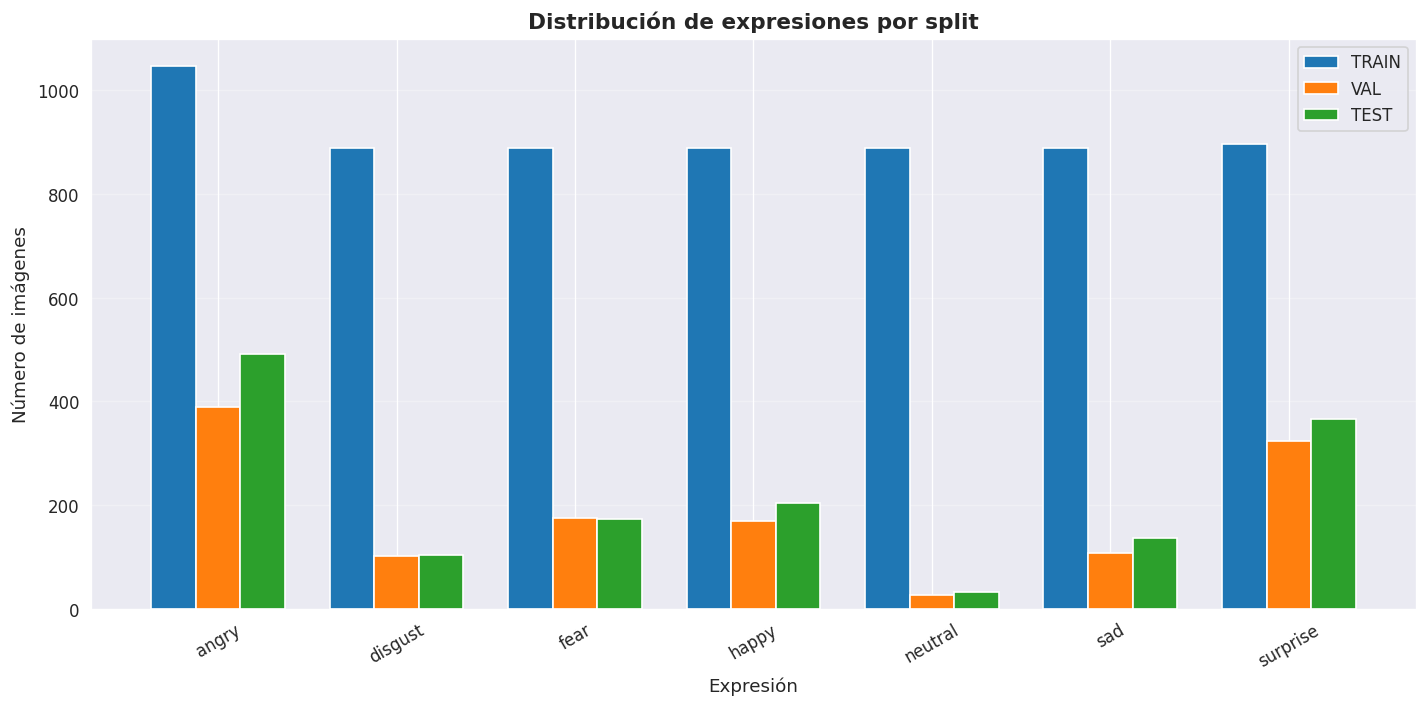

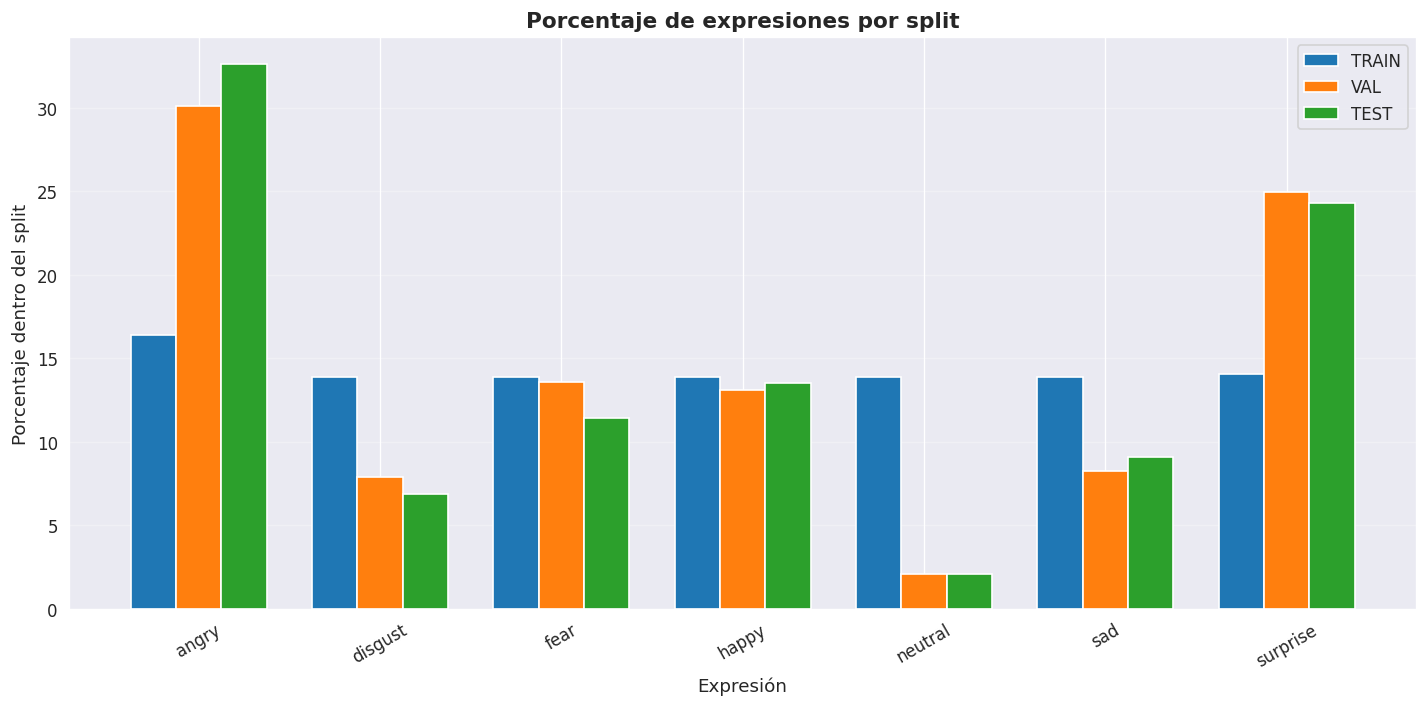


📦 REVISIÓN DE BOUNDING BOXES COMO IMAGEN COMPLETA
split class_name  n_labels  area_media  area_mediana  pct_bbox_full
 test   INVALIDA       357      0.9980        0.9980         100.00
 test      angry       492      0.9980        0.9980         100.00
 test    disgust       104      0.9980        0.9980         100.00
 test       fear       173      0.9980        0.9980         100.00
 test      happy       204      0.9980        0.9980         100.00
 test    neutral        32      0.9980        0.9980         100.00
 test        sad       137      0.9980        0.9980         100.00
 test   surprise       367      0.9980        0.9980         100.00
train   INVALIDA       784      0.9980        0.9980         100.00
train      angry      1047      0.9980        0.9980         100.00
train    disgust      2193      0.4245        0.0743          40.54
train       fear      1699      0.5381        0.9476          52.32
train      happy      1729      0.5292        0.9332          51.

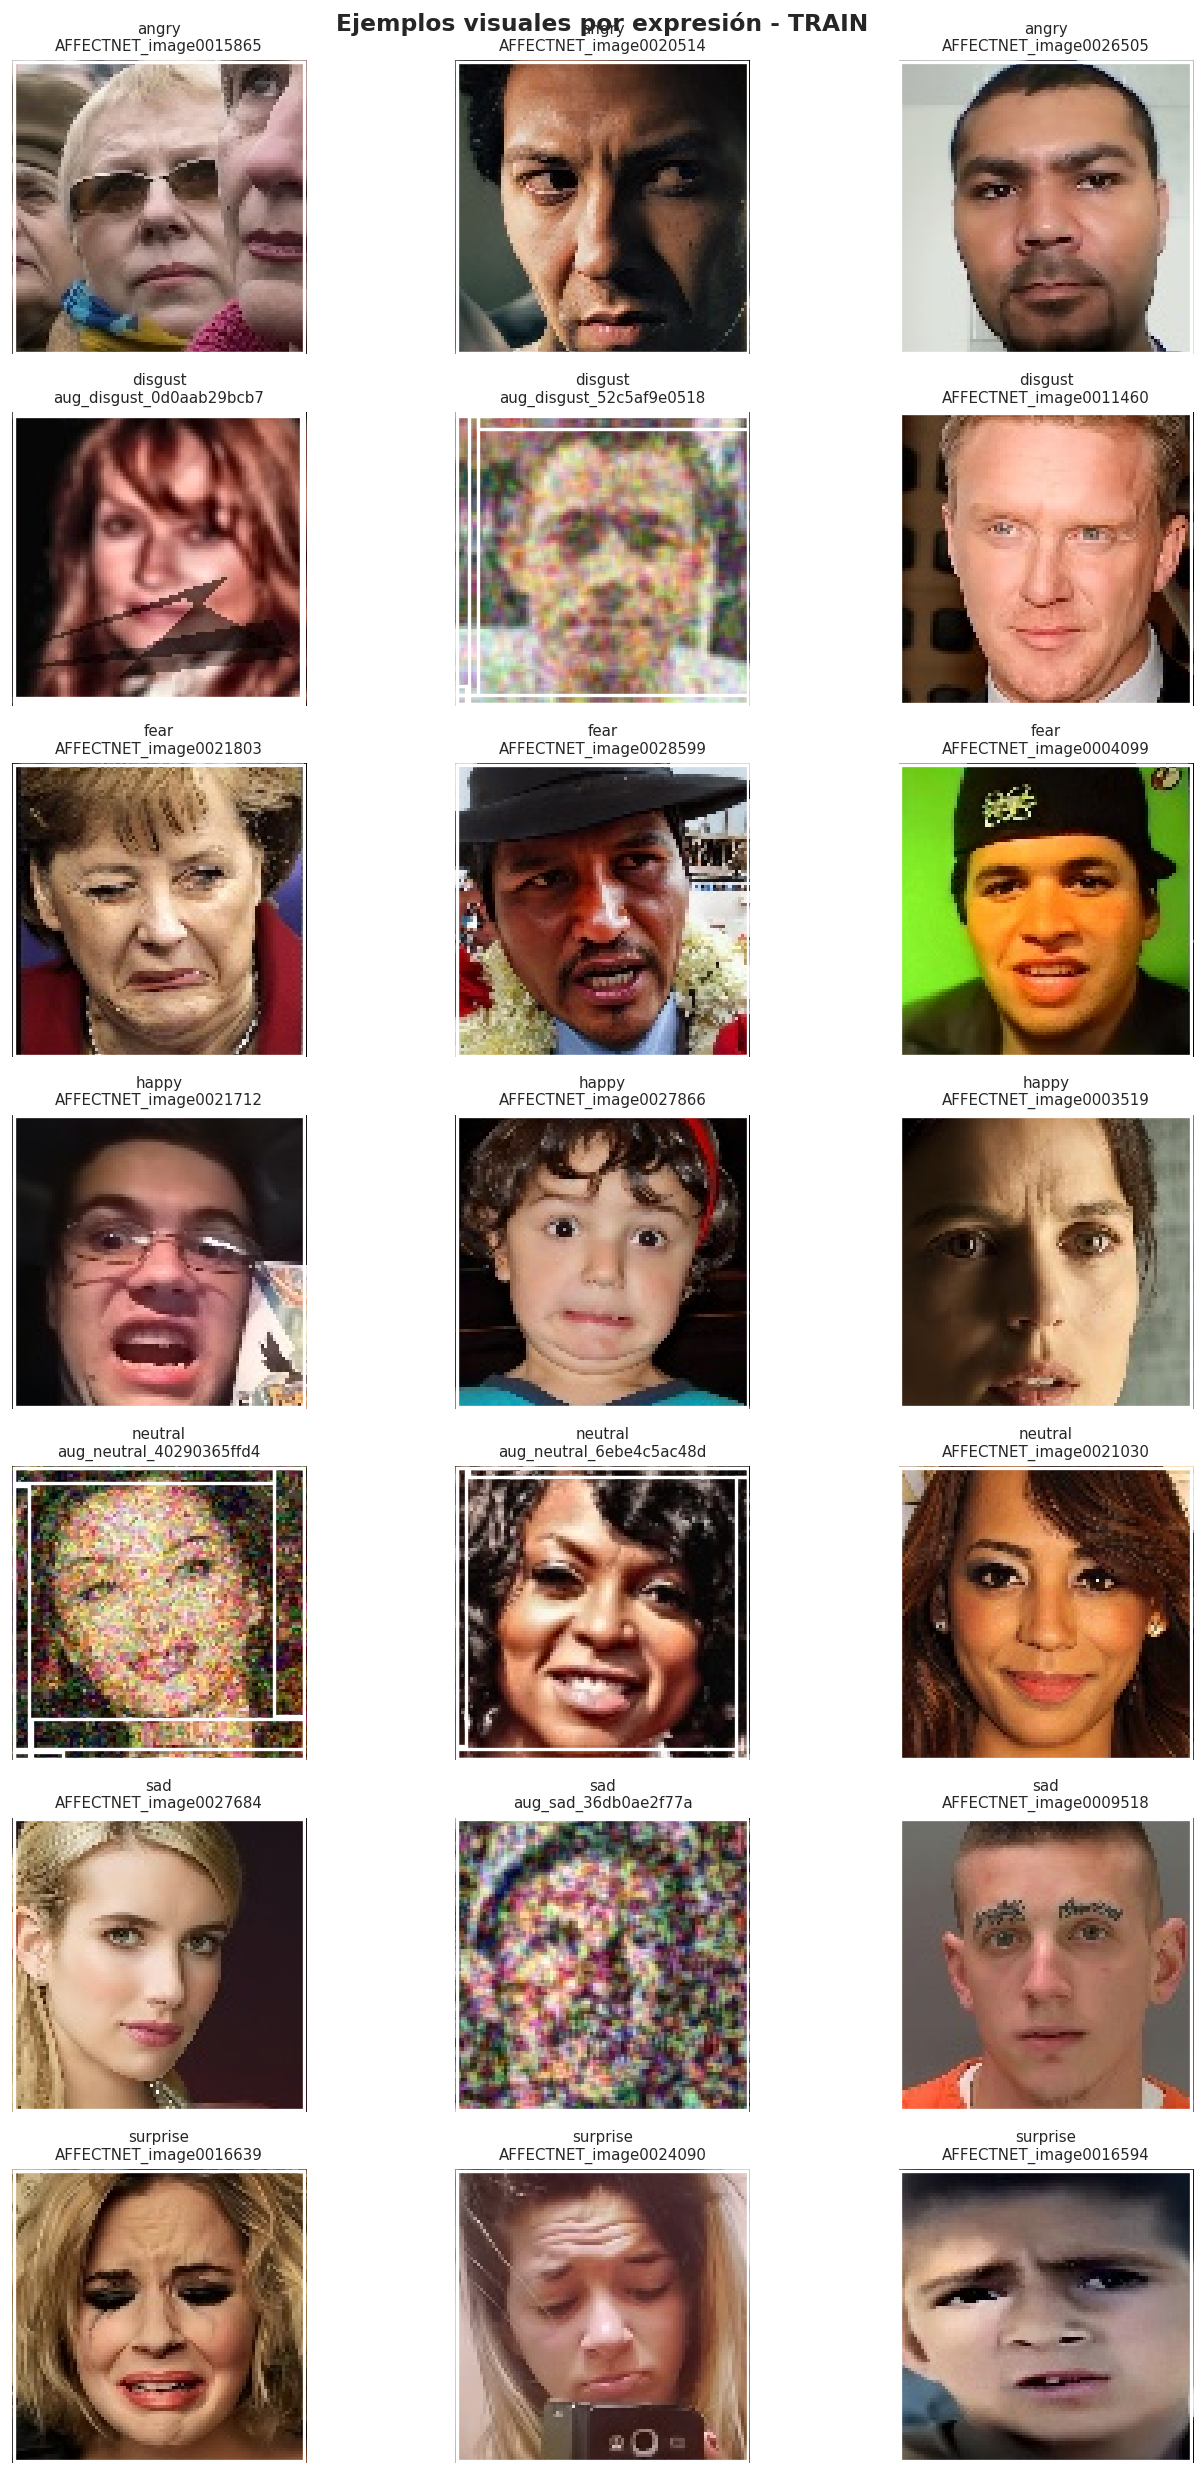


✅ DIAGNÓSTICO FINAL
Resumen esperado para tu trabajo:
  - Lo importante es que cada imagen tenga una sola expresión correcta.
  - Las cajas grandes o de imagen completa no son un problema si estás usando YOLO como clasificador aproximado.
  - Sí sería un problema si quieres detección real de rostro/emoción localizada.

⚠️ Problemas encontrados:
  - train: hay 13453 imágenes sin clase válida.
  - train: hay 784 labels con class_id inválido.
  - val: hay 3390 imágenes sin clase válida.
  - val: hay 304 labels con class_id inválido.
  - test: hay 3844 imágenes sin clase válida.
  - test: hay 357 labels con class_id inválido.

Archivos generados:
  /content/eda_expresiones_distribucion.png
  /content/eda_expresiones_porcentaje.png
  /content/eda_ejemplos_expresiones_train.png

✅ Análisis de expresiones completado.


In [ ]:
# ============================================================
# CELDA 6 – Análisis del dataset de EXPRESIONES
#   En este trabajo NO interesa tanto la calidad espacial del bbox,
#   sino la clase de expresión facial.
#
#   Formato YOLO esperado:
#       class_id cx cy w h
#
#   Orden de clases esperado:
#       0 angry
#       1 disgust
#       2 fear
#       3 happy
#       4 neutral
#       5 sad
#       6 surprise
# ============================================================

import gc, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Configuración esperada
# ------------------------------------------------------------

CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(CLASS_NAMES)
SPLITS = ["train", "val", "test"]

print("🎭 Orden de clases usado:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")


# ------------------------------------------------------------
# 2. Helpers
# ------------------------------------------------------------

def buscar_imagen(stem, img_dir):
    exts = [
        ".jpg", ".jpeg", ".png", ".bmp", ".webp",
        ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
    ]
    for ext in exts:
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


def leer_label_yolo(path):
    """
    Lee un archivo .txt YOLO.
    Retorna lista de tuplas:
        (class_id, cx, cy, w, h)
    """
    filas = []

    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                try:
                    cid = int(float(parts[0]))
                    cx  = float(parts[1])
                    cy  = float(parts[2])
                    bw  = float(parts[3])
                    bh  = float(parts[4])

                    filas.append((cid, cx, cy, bw, bh))

                except ValueError:
                    continue

    except Exception:
        pass

    return filas


def leer_split_expresiones(split):
    """
    Lee imágenes y labels de un split.
    Devuelve:
        df_labels: una fila por bbox/label
        df_imgs: una fila por imagen
    """

    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    filas_labels = []
    filas_imgs = []

    if not img_dir.exists():
        print(f"⚠️ No existe carpeta de imágenes: {img_dir}")
        return pd.DataFrame(), pd.DataFrame()

    if not lbl_dir.exists():
        print(f"⚠️ No existe carpeta de labels: {lbl_dir}")
        return pd.DataFrame(), pd.DataFrame()

    labels = sorted([p for p in lbl_dir.iterdir() if p.suffix.lower() == ".txt"])

    for lbl_path in tqdm(labels, desc=f"Leyendo {split}", leave=False):

        stem = lbl_path.stem
        img_path = buscar_imagen(stem, img_dir)

        bboxes = leer_label_yolo(lbl_path)

        tiene_img = img_path is not None

        clases = [bb[0] for bb in bboxes if 0 <= bb[0] < NUM_CLASSES]
        clases_unicas = sorted(set(clases))

        filas_imgs.append({
            "split": split,
            "stem": stem,
            "label_path": str(lbl_path),
            "image_path": str(img_path) if img_path else None,
            "tiene_imagen": tiene_img,
            "n_labels": len(bboxes),
            "n_clases_validas": len(clases),
            "clases_unicas": clases_unicas,
            "n_clases_unicas": len(clases_unicas),
            "class_id_principal": clases_unicas[0] if len(clases_unicas) == 1 else np.nan,
            "class_name_principal": CLASS_NAMES[clases_unicas[0]] if len(clases_unicas) == 1 else None,
            "multi_clase": len(clases_unicas) > 1,
            "sin_clase_valida": len(clases_unicas) == 0
        })

        for cid, cx, cy, bw, bh in bboxes:

            clase_valida = 0 <= cid < NUM_CLASSES
            area = bw * bh if bw > 0 and bh > 0 else np.nan

            # Caja casi de imagen completa.
            # Esto NO necesariamente es malo si tu tarea es clasificación.
            bbox_full_img = (
                0.45 <= cx <= 0.55 and
                0.45 <= cy <= 0.55 and
                bw >= 0.90 and
                bh >= 0.90
            )

            filas_labels.append({
                "split": split,
                "stem": stem,
                "image_path": str(img_path) if img_path else None,
                "class_id": cid,
                "class_name": CLASS_NAMES[cid] if clase_valida else "INVALIDA",
                "cx": cx,
                "cy": cy,
                "bw": bw,
                "bh": bh,
                "area": area,
                "bbox_full_img": bbox_full_img,
                "clase_valida": clase_valida,
                "tiene_imagen": tiene_img
            })

    df_labels = pd.DataFrame(filas_labels)
    df_imgs = pd.DataFrame(filas_imgs)

    return df_labels, df_imgs


# ------------------------------------------------------------
# 3. Lectura completa
# ------------------------------------------------------------

print("\n📦 Leyendo dataset de expresiones...")

dfs_labels = {}
dfs_imgs = {}

for split in SPLITS:
    df_l, df_i = leer_split_expresiones(split)
    dfs_labels[split] = df_l
    dfs_imgs[split] = df_i

    print(f"  {split.upper():<6} labels={len(df_l):,}  imágenes_con_label={len(df_i):,}")

df_labels_all = pd.concat(dfs_labels.values(), ignore_index=True)
df_imgs_all = pd.concat(dfs_imgs.values(), ignore_index=True)


# ------------------------------------------------------------
# 4. Resumen de salud del dataset
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🧪 REVISIÓN DE CONSISTENCIA DEL DATASET")
print("=" * 80)

for split in SPLITS:
    df_i = dfs_imgs[split]
    df_l = dfs_labels[split]

    if df_i.empty:
        print(f"\n{split.upper()}: sin datos.")
        continue

    total_imgs_label = len(df_i)
    sin_img = (~df_i["tiene_imagen"]).sum()
    sin_clase = df_i["sin_clase_valida"].sum()
    multi_clase = df_i["multi_clase"].sum()

    labels_invalidos = 0
    full_boxes = 0
    pct_full_boxes = 0

    if not df_l.empty:
        labels_invalidos = (~df_l["clase_valida"]).sum()
        full_boxes = df_l["bbox_full_img"].sum()
        pct_full_boxes = 100 * full_boxes / len(df_l)

    print(f"\n📁 {split.upper()}")
    print(f"  Imágenes con archivo label       : {total_imgs_label:,}")
    print(f"  Labels totales                   : {len(df_l):,}")
    print(f"  Labels sin imagen correspondiente: {sin_img:,}")
    print(f"  Imágenes sin clase válida        : {sin_clase:,}")
    print(f"  Imágenes con múltiples clases    : {multi_clase:,}")
    print(f"  Labels con class_id inválido     : {labels_invalidos:,}")
    print(f"  BBoxes casi imagen completa      : {full_boxes:,} ({pct_full_boxes:.2f}%)")

    if pct_full_boxes > 80:
        print("  ✅ Esto es compatible con una tarea tipo clasificación por expresión.")
    else:
        print("  ⚠️ Hay muchas cajas que NO cubren toda la imagen. Revisa si eso es intencional.")


# ------------------------------------------------------------
# 5. Distribución de clases por split
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🎭 DISTRIBUCIÓN DE EXPRESIONES POR SPLIT")
print("=" * 80)

resumen = []

for split in SPLITS:
    df = dfs_imgs[split].copy()

    # Para clasificación, contamos una imagen una vez.
    # Solo usamos imágenes que tengan una única clase válida.
    df_valid = df[
        (df["tiene_imagen"] == True) &
        (df["sin_clase_valida"] == False) &
        (df["multi_clase"] == False)
    ].copy()

    conteo = df_valid["class_id_principal"].value_counts().to_dict()

    for cid, cname in enumerate(CLASS_NAMES):
        resumen.append({
            "split": split,
            "class_id": cid,
            "class_name": cname,
            "n_imagenes": int(conteo.get(cid, 0))
        })

df_resumen = pd.DataFrame(resumen)

tabla = df_resumen.pivot(
    index="class_name",
    columns="split",
    values="n_imagenes"
).fillna(0).astype(int)

tabla = tabla.reindex(CLASS_NAMES)

tabla["total"] = tabla.sum(axis=1)

print(tabla.to_string())


# ------------------------------------------------------------
# 6. Porcentaje por clase dentro de cada split
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📊 PORCENTAJE POR CLASE DENTRO DE CADA SPLIT")
print("=" * 80)

tabla_pct = tabla[SPLITS].copy()

for split in SPLITS:
    total_split = tabla_pct[split].sum()
    if total_split > 0:
        tabla_pct[split] = (tabla_pct[split] / total_split * 100).round(2)
    else:
        tabla_pct[split] = 0

print(tabla_pct.to_string())


# ------------------------------------------------------------
# 7. Gráfico: distribución de clases por split
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(NUM_CLASSES)
width = 0.25

for idx, split in enumerate(SPLITS):
    valores = [
        int(df_resumen[
            (df_resumen["split"] == split) &
            (df_resumen["class_id"] == cid)
        ]["n_imagenes"].values[0])
        for cid in range(NUM_CLASSES)
    ]

    ax.bar(
        x + (idx - 1) * width,
        valores,
        width,
        label=split.upper()
    )

ax.set_title("Distribución de expresiones por split", fontweight="bold")
ax.set_xlabel("Expresión")
ax.set_ylabel("Número de imágenes")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/eda_expresiones_distribucion.png", dpi=120, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 8. Gráfico: porcentaje por clase
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

for idx, split in enumerate(SPLITS):
    valores = tabla_pct[split].values

    ax.bar(
        x + (idx - 1) * width,
        valores,
        width,
        label=split.upper()
    )

ax.set_title("Porcentaje de expresiones por split", fontweight="bold")
ax.set_xlabel("Expresión")
ax.set_ylabel("Porcentaje dentro del split")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/eda_expresiones_porcentaje.png", dpi=120, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 9. Verificación específica de cajas completas
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📦 REVISIÓN DE BOUNDING BOXES COMO IMAGEN COMPLETA")
print("=" * 80)

if not df_labels_all.empty:
    resumen_bbox = df_labels_all.groupby(["split", "class_name"]).agg(
        n_labels=("class_id", "count"),
        area_media=("area", "mean"),
        area_mediana=("area", "median"),
        pct_bbox_full=("bbox_full_img", lambda x: 100 * x.mean())
    ).reset_index()

    resumen_bbox["area_media"] = resumen_bbox["area_media"].round(4)
    resumen_bbox["area_mediana"] = resumen_bbox["area_mediana"].round(4)
    resumen_bbox["pct_bbox_full"] = resumen_bbox["pct_bbox_full"].round(2)

    print(resumen_bbox.to_string(index=False))

    print("\nInterpretación:")
    print("  - Si pct_bbox_full es alto, tus labels funcionan como clasificación de imagen completa.")
    print("  - Si pct_bbox_full es bajo, hay cajas parciales y debes revisar si representan la cara correctamente.")
else:
    print("No hay labels para analizar.")


# ------------------------------------------------------------
# 10. Visualizar ejemplos por clase
# ------------------------------------------------------------

def mostrar_ejemplos_por_clase(split="train", n_por_clase=3, dibujar_bbox=True):
    df = dfs_imgs[split].copy()

    df = df[
        (df["tiene_imagen"] == True) &
        (df["sin_clase_valida"] == False) &
        (df["multi_clase"] == False)
    ].copy()

    if df.empty:
        print(f"⚠️ No hay ejemplos válidos en {split}.")
        return

    fig, axes = plt.subplots(
        NUM_CLASSES,
        n_por_clase,
        figsize=(4 * n_por_clase, 3 * NUM_CLASSES)
    )

    if NUM_CLASSES == 1:
        axes = np.array([axes])

    for cid, cname in enumerate(CLASS_NAMES):
        muestras = df[df["class_id_principal"] == cid]

        if len(muestras) == 0:
            for j in range(n_por_clase):
                axes[cid, j].axis("off")
            continue

        muestras = muestras.sample(
            min(n_por_clase, len(muestras)),
            random_state=42
        )

        muestras = muestras.to_dict("records")

        for j in range(n_por_clase):
            ax = axes[cid, j]
            ax.axis("off")

            if j >= len(muestras):
                continue

            row = muestras[j]
            img_path = row["image_path"]
            stem = row["stem"]

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]

            ax.imshow(img)
            ax.set_title(f"{cname}\n{stem}", fontsize=9)

            if dibujar_bbox:
                lbl_path = Path(row["label_path"])
                bbs = leer_label_yolo(lbl_path)

                for bb in bbs:
                    bb_cid, cx, cy, bw, bh = bb

                    if bb_cid != cid:
                        continue

                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)

                    x1 = max(0, min(w - 1, x1))
                    y1 = max(0, min(h - 1, y1))
                    x2 = max(0, min(w - 1, x2))
                    y2 = max(0, min(h - 1, y2))

                    rect = plt.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        fill=False,
                        linewidth=2
                    )
                    ax.add_patch(rect)

    plt.suptitle(
        f"Ejemplos visuales por expresión - {split.upper()}",
        fontsize=14,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"/content/eda_ejemplos_expresiones_{split}.png", dpi=120, bbox_inches="tight")
    plt.show()


mostrar_ejemplos_por_clase(split="train", n_por_clase=3, dibujar_bbox=True)


# ------------------------------------------------------------
# 11. Diagnóstico final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("✅ DIAGNÓSTICO FINAL")
print("=" * 80)

problemas = []

for split in SPLITS:
    df_i = dfs_imgs[split]
    df_l = dfs_labels[split]

    if df_i.empty:
        problemas.append(f"{split}: no tiene datos.")
        continue

    sin_img = (~df_i["tiene_imagen"]).sum()
    sin_clase = df_i["sin_clase_valida"].sum()
    multi_clase = df_i["multi_clase"].sum()

    if sin_img > 0:
        problemas.append(f"{split}: hay {sin_img} labels sin imagen.")

    if sin_clase > 0:
        problemas.append(f"{split}: hay {sin_clase} imágenes sin clase válida.")

    if multi_clase > 0:
        problemas.append(f"{split}: hay {multi_clase} imágenes con múltiples clases.")

    if not df_l.empty:
        invalidas = (~df_l["clase_valida"]).sum()
        if invalidas > 0:
            problemas.append(f"{split}: hay {invalidas} labels con class_id inválido.")

print("Resumen esperado para tu trabajo:")
print("  - Lo importante es que cada imagen tenga una sola expresión correcta.")
print("  - Las cajas grandes o de imagen completa no son un problema si estás usando YOLO como clasificador aproximado.")
print("  - Sí sería un problema si quieres detección real de rostro/emoción localizada.")

if problemas:
    print("\n⚠️ Problemas encontrados:")
    for p in problemas:
        print(f"  - {p}")
else:
    print("\n✅ No se encontraron problemas graves de estructura.")

print("\nArchivos generados:")
print("  /content/eda_expresiones_distribucion.png")
print("  /content/eda_expresiones_porcentaje.png")
print("  /content/eda_ejemplos_expresiones_train.png")

gc.collect()
print("\n✅ Análisis de expresiones completado.")

# 🔍 Sección 7 – Validación de Integridad del Dataset

Mounted at /content/drive
📁 CONFIGURACIÓN DEL DATASET
Ruta YOLO: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
¿Existe ruta YOLO?: True

Estructura esperada:
 images/train: True
 images/val  : True
 images/test : True
 labels/train: True
 labels/val  : True
 labels/test : True

🎭 Clases:
   0: angry
   1: disgust
   2: fear
   3: happy
   4: neutral
   5: sad
   6: surprise

🔍 VALIDACIÓN DE INTEGRIDAD POR SPLIT

🔹 TRAIN
   📂 Carpeta imágenes : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/images/train
   📂 Carpeta labels   : /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED/labels/train
   📸 Imágenes                  : 19,842
   🏷️ Labels                    : 19,842
   ✅ Coincidencias             : 19,842
   ✅ Imágenes sin label        : 0
   ✅ Labels sin imagen        : 0
   ✅ Labels vacíos          : 0
   ⚠️ Labels inválidos       : 13,453
   ⚠️ Imgs sin clase válida : 13,453
   ✅ Imgs multi-expresión  : 0
   ⚠️ Imgs con >1 label     

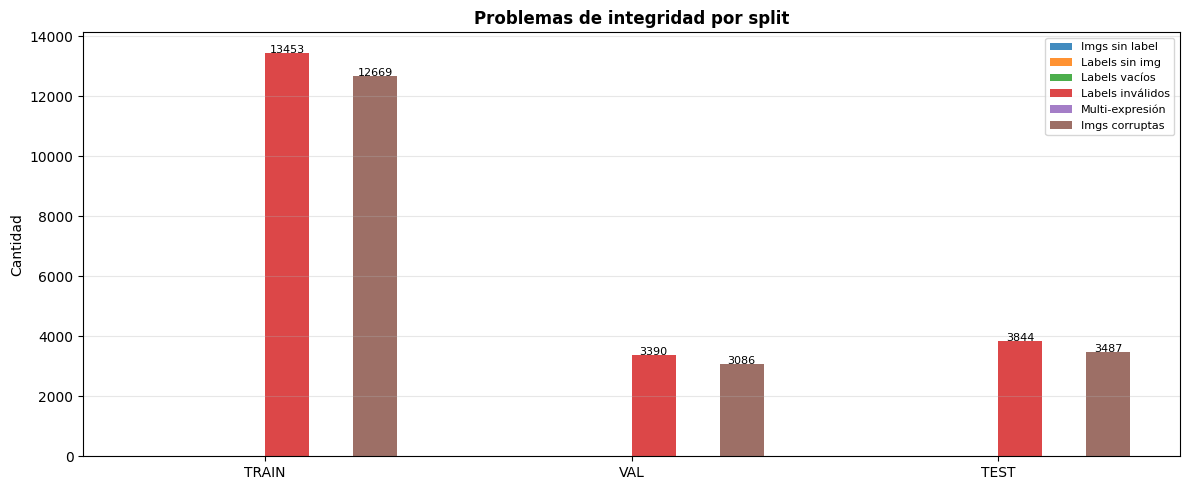

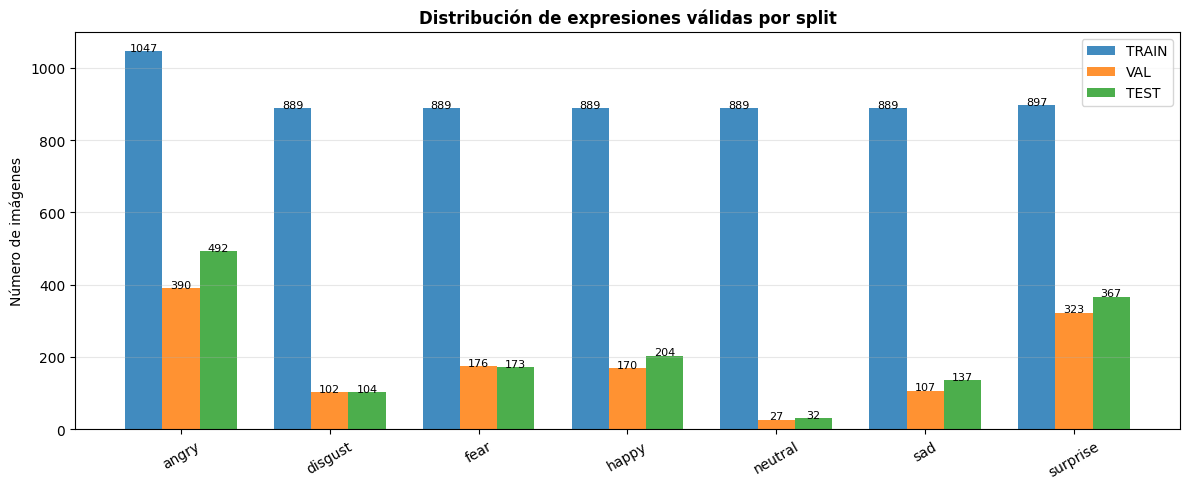


📄 Reporte de problemas guardado en:
   /content/reporte_problemas_integridad.csv

✅ DIAGNÓSTICO FINAL PARA EXPRESIONES
⚠️ Se encontraron puntos a revisar:
   - train: 13453 labels inválidos
   - train: 12669 imágenes corruptas
   - val: 3390 labels inválidos
   - val: 3086 imágenes corruptas
   - test: 3844 labels inválidos
   - test: 3487 imágenes corruptas

Interpretación para tu trabajo:

  - Si una imagen representa una sola emoción, debe tener una sola clase válida.
  - Para expresiones faciales, los labels vacíos normalmente NO son deseables.
  - Las cajas tipo imagen completa no son graves si estás usando YOLO como clasificación aproximada.
  - Lo más importante es que el class_id corresponda bien al orden:
        0 angry
        1 disgust
        2 fear
        3 happy
        4 neutral
        5 sad
        6 surprise

📊 Gráficos guardados:
   /content/eda_integridad_expresiones.png
   /content/eda_distribucion_expresiones_validas.png

✅ Validación de integridad completada.


In [4]:
# ============================================================
# CELDA 7 – Validación de integridad para dataset de EXPRESIONES
# Ruta ajustada según Google Drive:
# /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 0. Montar Google Drive si estás en Colab
# ------------------------------------------------------------

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("ℹ️ No se montó Drive automáticamente. Si ya está montado, no hay problema.")


# ------------------------------------------------------------
# 1. Configuración correcta del dataset
# ------------------------------------------------------------

YOLO = Path("/content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED")

SPLITS = ["train", "val", "test"]

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 70)
print("📁 CONFIGURACIÓN DEL DATASET")
print("=" * 70)
print("Ruta YOLO:", YOLO)
print("¿Existe ruta YOLO?:", YOLO.exists())

print("\nEstructura esperada:")
print(" images/train:", (YOLO / "images" / "train").exists())
print(" images/val  :", (YOLO / "images" / "val").exists())
print(" images/test :", (YOLO / "images" / "test").exists())
print(" labels/train:", (YOLO / "labels" / "train").exists())
print(" labels/val  :", (YOLO / "labels" / "val").exists())
print(" labels/test :", (YOLO / "labels" / "test").exists())

print("\n🎭 Clases:")
for i, c in enumerate(CLASS_NAMES):
    print(f"   {i}: {c}")


# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------

def leer_label_yolo(label_path):
    """
    Lee un archivo .txt en formato YOLO:
        class_id cx cy w h
    """
    registros = []

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as fh:
            for line_num, line in enumerate(fh, start=1):
                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                if len(parts) != 5:
                    registros.append({
                        "class_id": None,
                        "cx": None,
                        "cy": None,
                        "bw": None,
                        "bh": None,
                        "linea": line_num,
                        "valida": False,
                        "motivo": "formato_incorrecto"
                    })
                    continue

                try:
                    class_id = int(float(parts[0]))
                    cx = float(parts[1])
                    cy = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])

                    clase_valida = 0 <= class_id < NUM_CLASSES

                    coords_validas = (
                        0 <= cx <= 1 and
                        0 <= cy <= 1 and
                        0 < bw <= 1 and
                        0 < bh <= 1
                    )

                    if not clase_valida:
                        motivo = "class_id_invalido"
                    elif not coords_validas:
                        motivo = "coordenadas_invalidas"
                    else:
                        motivo = "ok"

                    registros.append({
                        "class_id": class_id,
                        "cx": cx,
                        "cy": cy,
                        "bw": bw,
                        "bh": bh,
                        "linea": line_num,
                        "valida": clase_valida and coords_validas,
                        "motivo": motivo
                    })

                except ValueError:
                    registros.append({
                        "class_id": None,
                        "cx": None,
                        "cy": None,
                        "bw": None,
                        "bh": None,
                        "linea": line_num,
                        "valida": False,
                        "motivo": "valor_no_numerico"
                    })

    except Exception:
        registros.append({
            "class_id": None,
            "cx": None,
            "cy": None,
            "bw": None,
            "bh": None,
            "linea": None,
            "valida": False,
            "motivo": "error_lectura"
        })

    return registros


def obtener_stems_imagenes(img_dir):
    if not img_dir.exists():
        return set()

    return {
        p.stem
        for p in img_dir.iterdir()
        if p.is_file() and p.suffix in IMG_EXTS
    }


def obtener_stems_labels(lbl_dir):
    if not lbl_dir.exists():
        return set()

    return {
        p.stem
        for p in lbl_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    }


def verificar_imagen_corrupta(path_img):
    try:
        with Image.open(path_img) as im:
            im.verify()
        return False
    except Exception:
        return True


# ------------------------------------------------------------
# 3. Validación principal
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔍 VALIDACIÓN DE INTEGRIDAD POR SPLIT")
print("=" * 70)

reporte_integridad = {}
filas_detalle = []

for split in SPLITS:
    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    imgs_stems = obtener_stems_imagenes(img_dir)
    lbls_stems = obtener_stems_labels(lbl_dir)

    sin_label = imgs_stems - lbls_stems
    sin_imagen = lbls_stems - imgs_stems
    coinciden = imgs_stems & lbls_stems

    labels_vacios = 0
    labels_invalidos = 0
    imagenes_multi_clase = 0
    imagenes_sin_clase_valida = 0
    imagenes_con_mas_de_un_label = 0

    clases_por_split = {i: 0 for i in range(NUM_CLASSES)}

    ejemplos_sin_label = sorted(list(sin_label))[:5]
    ejemplos_sin_imagen = sorted(list(sin_imagen))[:5]
    ejemplos_labels_vacios = []
    ejemplos_invalidos = []
    ejemplos_multi_clase = []
    ejemplos_corruptos = []

    for stem in coinciden:
        lbl_path = lbl_dir / f"{stem}.txt"

        if lbl_path.stat().st_size == 0:
            labels_vacios += 1
            imagenes_sin_clase_valida += 1

            if len(ejemplos_labels_vacios) < 5:
                ejemplos_labels_vacios.append(stem)

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "label_vacio"
            })

            continue

        registros = leer_label_yolo(lbl_path)

        registros_validos = [r for r in registros if r["valida"]]
        registros_invalidos = [r for r in registros if not r["valida"]]

        if len(registros_invalidos) > 0:
            labels_invalidos += len(registros_invalidos)

            if len(ejemplos_invalidos) < 5:
                ejemplos_invalidos.append(stem)

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "label_invalido"
            })

        clases_validas = [r["class_id"] for r in registros_validos]
        clases_unicas = sorted(set(clases_validas))

        if len(clases_validas) == 0:
            imagenes_sin_clase_valida += 1

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "sin_clase_valida"
            })

        if len(clases_validas) > 1:
            imagenes_con_mas_de_un_label += 1

        if len(clases_unicas) > 1:
            imagenes_multi_clase += 1

            if len(ejemplos_multi_clase) < 5:
                ejemplos_multi_clase.append(stem)

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "multiples_expresiones"
            })

        # Para tu caso: contamos solo imágenes con una única expresión válida.
        if len(clases_unicas) == 1:
            clases_por_split[clases_unicas[0]] += 1

    corruptos = 0

    if img_dir.exists():
        for p in img_dir.iterdir():
            if not p.is_file():
                continue

            if p.suffix not in IMG_EXTS:
                continue

            if verificar_imagen_corrupta(p):
                corruptos += 1

                if len(ejemplos_corruptos) < 5:
                    ejemplos_corruptos.append(p.name)

                filas_detalle.append({
                    "split": split,
                    "stem": p.stem,
                    "problema": "imagen_corrupta"
                })

    reporte_integridad[split] = {
        "total_imgs": len(imgs_stems),
        "total_lbls": len(lbls_stems),
        "coincidencias": len(coinciden),
        "sin_label": len(sin_label),
        "sin_imagen": len(sin_imagen),
        "labels_vacios": labels_vacios,
        "labels_invalidos": labels_invalidos,
        "imagenes_sin_clase_valida": imagenes_sin_clase_valida,
        "imagenes_con_mas_de_un_label": imagenes_con_mas_de_un_label,
        "imagenes_multi_clase": imagenes_multi_clase,
        "corruptos": corruptos,
        "clases": clases_por_split,
        "ejemplos_sin_label": ejemplos_sin_label,
        "ejemplos_sin_imagen": ejemplos_sin_imagen,
        "ejemplos_labels_vacios": ejemplos_labels_vacios,
        "ejemplos_invalidos": ejemplos_invalidos,
        "ejemplos_multi_clase": ejemplos_multi_clase,
        "ejemplos_corruptos": ejemplos_corruptos
    }

    r = reporte_integridad[split]

    print(f"\n🔹 {split.upper()}")

    print(f"   📂 Carpeta imágenes : {img_dir}")
    print(f"   📂 Carpeta labels   : {lbl_dir}")

    print(f"   📸 Imágenes                  : {r['total_imgs']:,}")
    print(f"   🏷️ Labels                    : {r['total_lbls']:,}")
    print(f"   ✅ Coincidencias             : {r['coincidencias']:,}")
    print(f"   {'⚠️' if r['sin_label'] > 0 else '✅'} Imágenes sin label        : {r['sin_label']:,}")
    print(f"   {'⚠️' if r['sin_imagen'] > 0 else '✅'} Labels sin imagen        : {r['sin_imagen']:,}")
    print(f"   {'⚠️' if r['labels_vacios'] > 0 else '✅'} Labels vacíos          : {r['labels_vacios']:,}")
    print(f"   {'⚠️' if r['labels_invalidos'] > 0 else '✅'} Labels inválidos       : {r['labels_invalidos']:,}")
    print(f"   {'⚠️' if r['imagenes_sin_clase_valida'] > 0 else '✅'} Imgs sin clase válida : {r['imagenes_sin_clase_valida']:,}")
    print(f"   {'⚠️' if r['imagenes_multi_clase'] > 0 else '✅'} Imgs multi-expresión  : {r['imagenes_multi_clase']:,}")
    print(f"   {'⚠️' if r['imagenes_con_mas_de_un_label'] > 0 else '✅'} Imgs con >1 label      : {r['imagenes_con_mas_de_un_label']:,}")
    print(f"   {'❌' if r['corruptos'] > 0 else '✅'} Imágenes corruptas       : {r['corruptos']:,}")

    if r["ejemplos_sin_label"]:
        print(f"      Ejemplos imgs sin label  : {r['ejemplos_sin_label']}")

    if r["ejemplos_sin_imagen"]:
        print(f"      Ejemplos labels sin img  : {r['ejemplos_sin_imagen']}")

    if r["ejemplos_labels_vacios"]:
        print(f"      Ejemplos labels vacíos   : {r['ejemplos_labels_vacios']}")

    if r["ejemplos_invalidos"]:
        print(f"      Ejemplos labels inválidos: {r['ejemplos_invalidos']}")

    if r["ejemplos_multi_clase"]:
        print(f"      Ejemplos multi-expresión : {r['ejemplos_multi_clase']}")

    if r["ejemplos_corruptos"]:
        print(f"      Ejemplos corruptas       : {r['ejemplos_corruptos']}")


# ------------------------------------------------------------
# 4. Tabla distribución de expresiones válidas
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🎭 DISTRIBUCIÓN DE EXPRESIONES VÁLIDAS")
print("=" * 70)

filas_dist = []

for split in SPLITS:
    clases = reporte_integridad[split]["clases"]

    for cid, cname in enumerate(CLASS_NAMES):
        filas_dist.append({
            "split": split,
            "class_id": cid,
            "class_name": cname,
            "n": clases[cid]
        })

df_dist = pd.DataFrame(filas_dist)

tabla_dist = df_dist.pivot(
    index="class_name",
    columns="split",
    values="n"
).fillna(0).astype(int)

tabla_dist = tabla_dist.reindex(CLASS_NAMES)
tabla_dist["total"] = tabla_dist.sum(axis=1)

print(tabla_dist.to_string())


# ------------------------------------------------------------
# 5. Porcentaje por split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📊 PORCENTAJE POR EXPRESIÓN DENTRO DE CADA SPLIT")
print("=" * 70)

tabla_pct = tabla_dist[SPLITS].copy()

for split in SPLITS:
    total_split = tabla_pct[split].sum()

    if total_split > 0:
        tabla_pct[split] = (tabla_pct[split] / total_split * 100).round(2)
    else:
        tabla_pct[split] = 0

print(tabla_pct.to_string())


# ------------------------------------------------------------
# 6. Gráfica problemas de integridad
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

categorias = [
    "sin_label",
    "sin_imagen",
    "labels_vacios",
    "labels_invalidos",
    "imagenes_multi_clase",
    "corruptos"
]

etiquetas = [
    "Imgs sin label",
    "Labels sin img",
    "Labels vacíos",
    "Labels inválidos",
    "Multi-expresión",
    "Imgs corruptas"
]

x = np.arange(len(SPLITS))
w = 0.12

for i, (cat, etiqueta) in enumerate(zip(categorias, etiquetas)):
    vals = [reporte_integridad[s][cat] for s in SPLITS]

    bars = ax.bar(
        x + i * w - ((len(categorias) - 1) / 2) * w,
        vals,
        w,
        label=etiqueta,
        alpha=0.85
    )

    for bar in bars:
        if bar.get_height() > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(int(bar.get_height())),
                ha="center",
                fontsize=8
            )

ax.set_title("Problemas de integridad por split", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_ylabel("Cantidad")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/eda_integridad_expresiones.png", dpi=120, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 7. Gráfica distribución de expresiones
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(NUM_CLASSES)
w = 0.25

for i, split in enumerate(SPLITS):
    vals = [reporte_integridad[split]["clases"][cid] for cid in range(NUM_CLASSES)]

    bars = ax.bar(
        x + i * w - w,
        vals,
        w,
        label=split.upper(),
        alpha=0.85
    )

    for bar in bars:
        if bar.get_height() > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(int(bar.get_height())),
                ha="center",
                fontsize=8
            )

ax.set_title("Distribución de expresiones válidas por split", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylabel("Número de imágenes")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/eda_distribucion_expresiones_validas.png", dpi=120, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 8. Guardar reporte de problemas
# ------------------------------------------------------------

df_problemas = pd.DataFrame(filas_detalle)

if len(df_problemas) > 0:
    df_problemas.to_csv("/content/reporte_problemas_integridad.csv", index=False)
    print("\n📄 Reporte de problemas guardado en:")
    print("   /content/reporte_problemas_integridad.csv")
else:
    print("\n✅ No se generó CSV de problemas porque no se encontraron problemas.")


# ------------------------------------------------------------
# 9. Diagnóstico final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ DIAGNÓSTICO FINAL PARA EXPRESIONES")
print("=" * 70)

problemas_globales = []

for split in SPLITS:
    r = reporte_integridad[split]

    if r["sin_label"] > 0:
        problemas_globales.append(f"{split}: {r['sin_label']} imágenes sin label")

    if r["sin_imagen"] > 0:
        problemas_globales.append(f"{split}: {r['sin_imagen']} labels sin imagen")

    if r["labels_vacios"] > 0:
        problemas_globales.append(f"{split}: {r['labels_vacios']} labels vacíos")

    if r["labels_invalidos"] > 0:
        problemas_globales.append(f"{split}: {r['labels_invalidos']} labels inválidos")

    if r["imagenes_multi_clase"] > 0:
        problemas_globales.append(f"{split}: {r['imagenes_multi_clase']} imágenes con múltiples expresiones")

    if r["corruptos"] > 0:
        problemas_globales.append(f"{split}: {r['corruptos']} imágenes corruptas")

if problemas_globales:
    print("⚠️ Se encontraron puntos a revisar:")
    for p in problemas_globales:
        print(f"   - {p}")
else:
    print("✅ La estructura del dataset se ve consistente.")

print("""
Interpretación para tu trabajo:

  - Si una imagen representa una sola emoción, debe tener una sola clase válida.
  - Para expresiones faciales, los labels vacíos normalmente NO son deseables.
  - Las cajas tipo imagen completa no son graves si estás usando YOLO como clasificación aproximada.
  - Lo más importante es que el class_id corresponda bien al orden:
        0 angry
        1 disgust
        2 fear
        3 happy
        4 neutral
        5 sad
        6 surprise
""")

print("📊 Gráficos guardados:")
print("   /content/eda_integridad_expresiones.png")
print("   /content/eda_distribucion_expresiones_validas.png")

print("\n✅ Validación de integridad completada.")

# 🎨 Sección 8 – Visualización de Imágenes con Bounding Boxes

/tmp/ipykernel_9691/1616592163.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  PALETA_CLASES = plt.cm.get_cmap("tab10", NUM_CLASSES)
/tmp/ipykernel_9691/1616592163.py:56: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


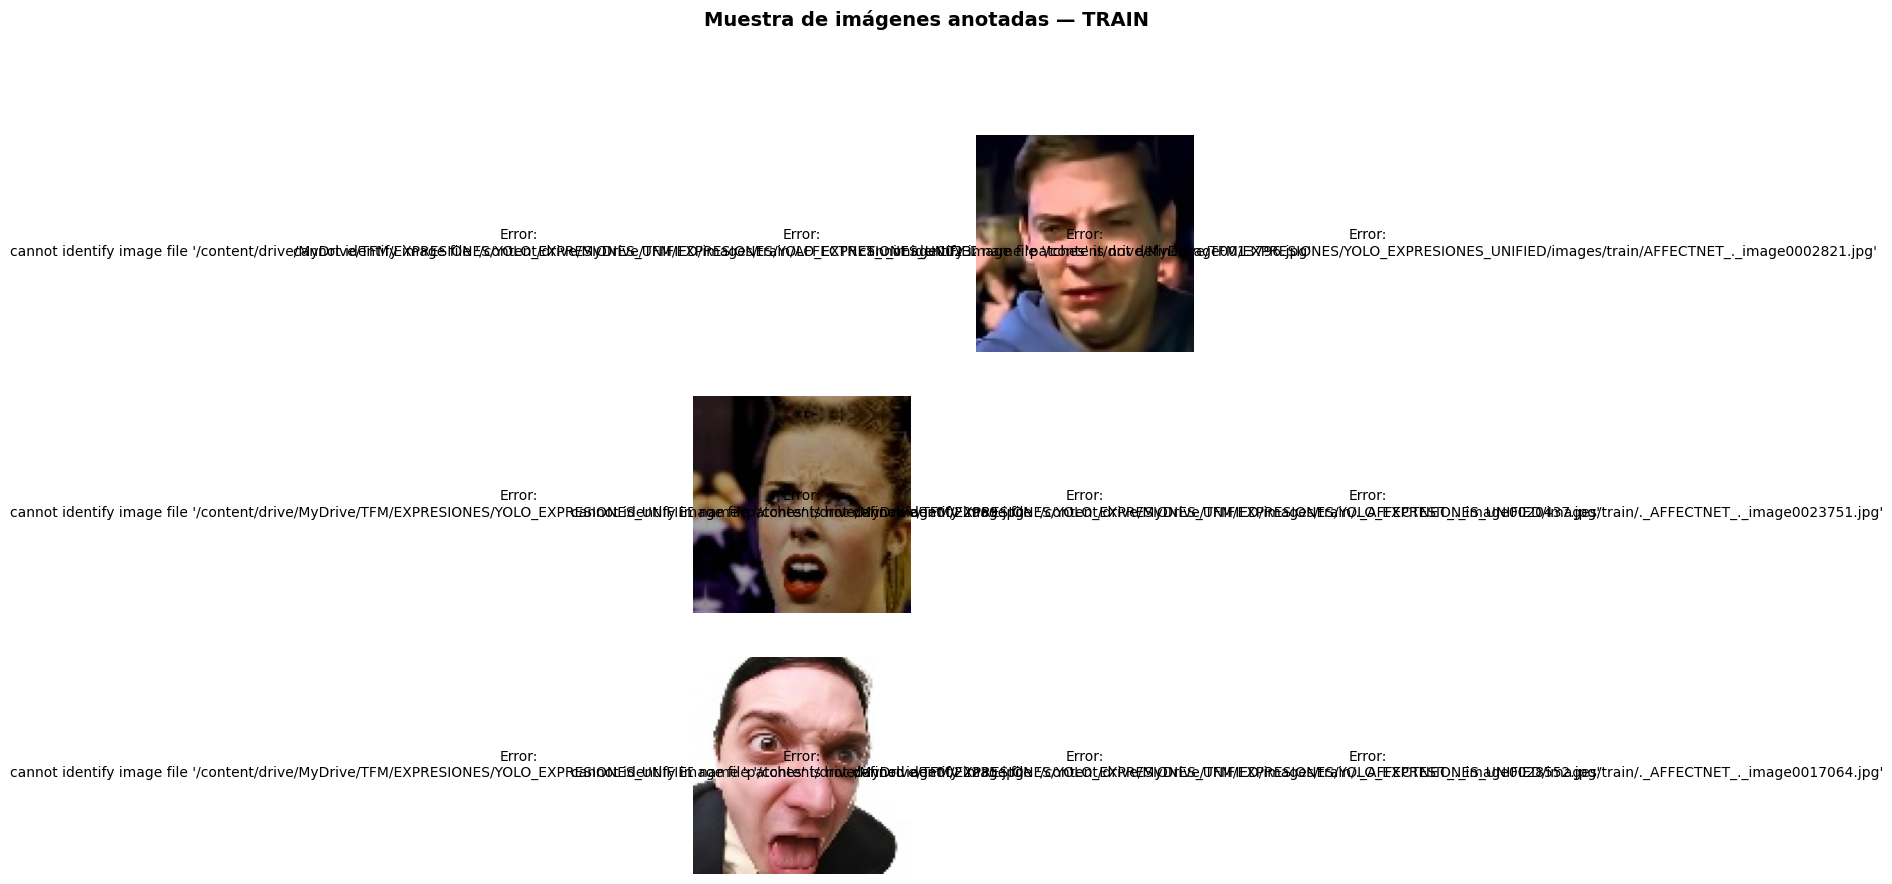

  📸 Guardado: /content/eda_muestra_train.png


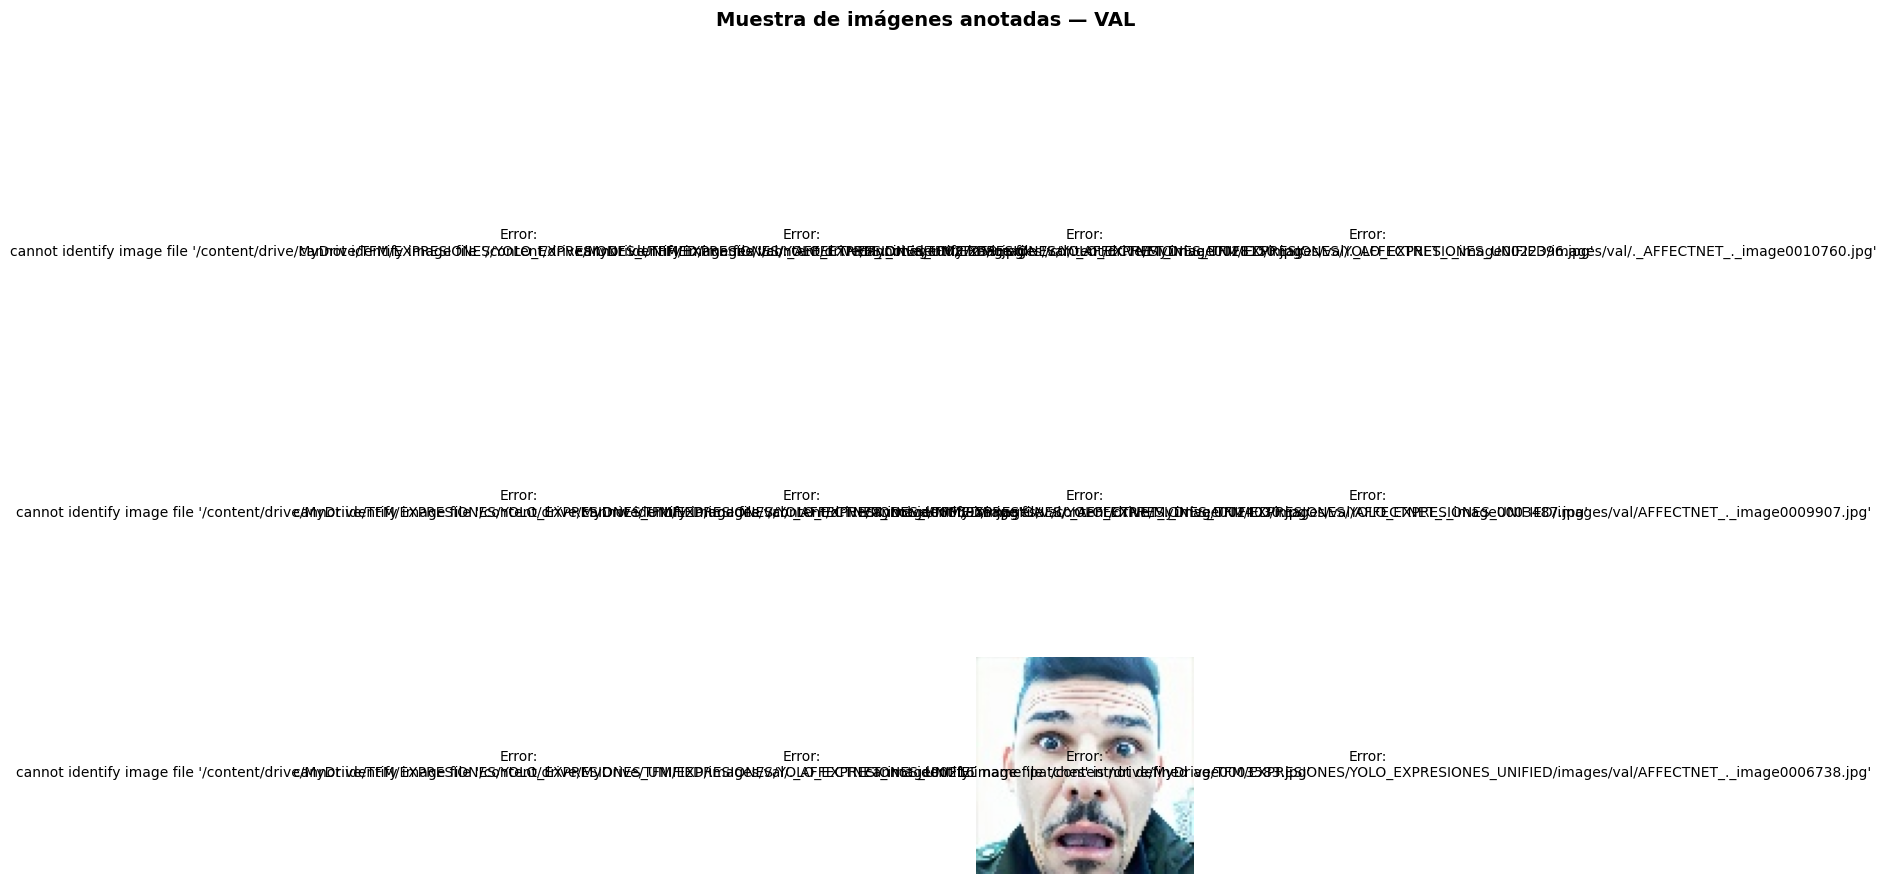

  📸 Guardado: /content/eda_muestra_val.png


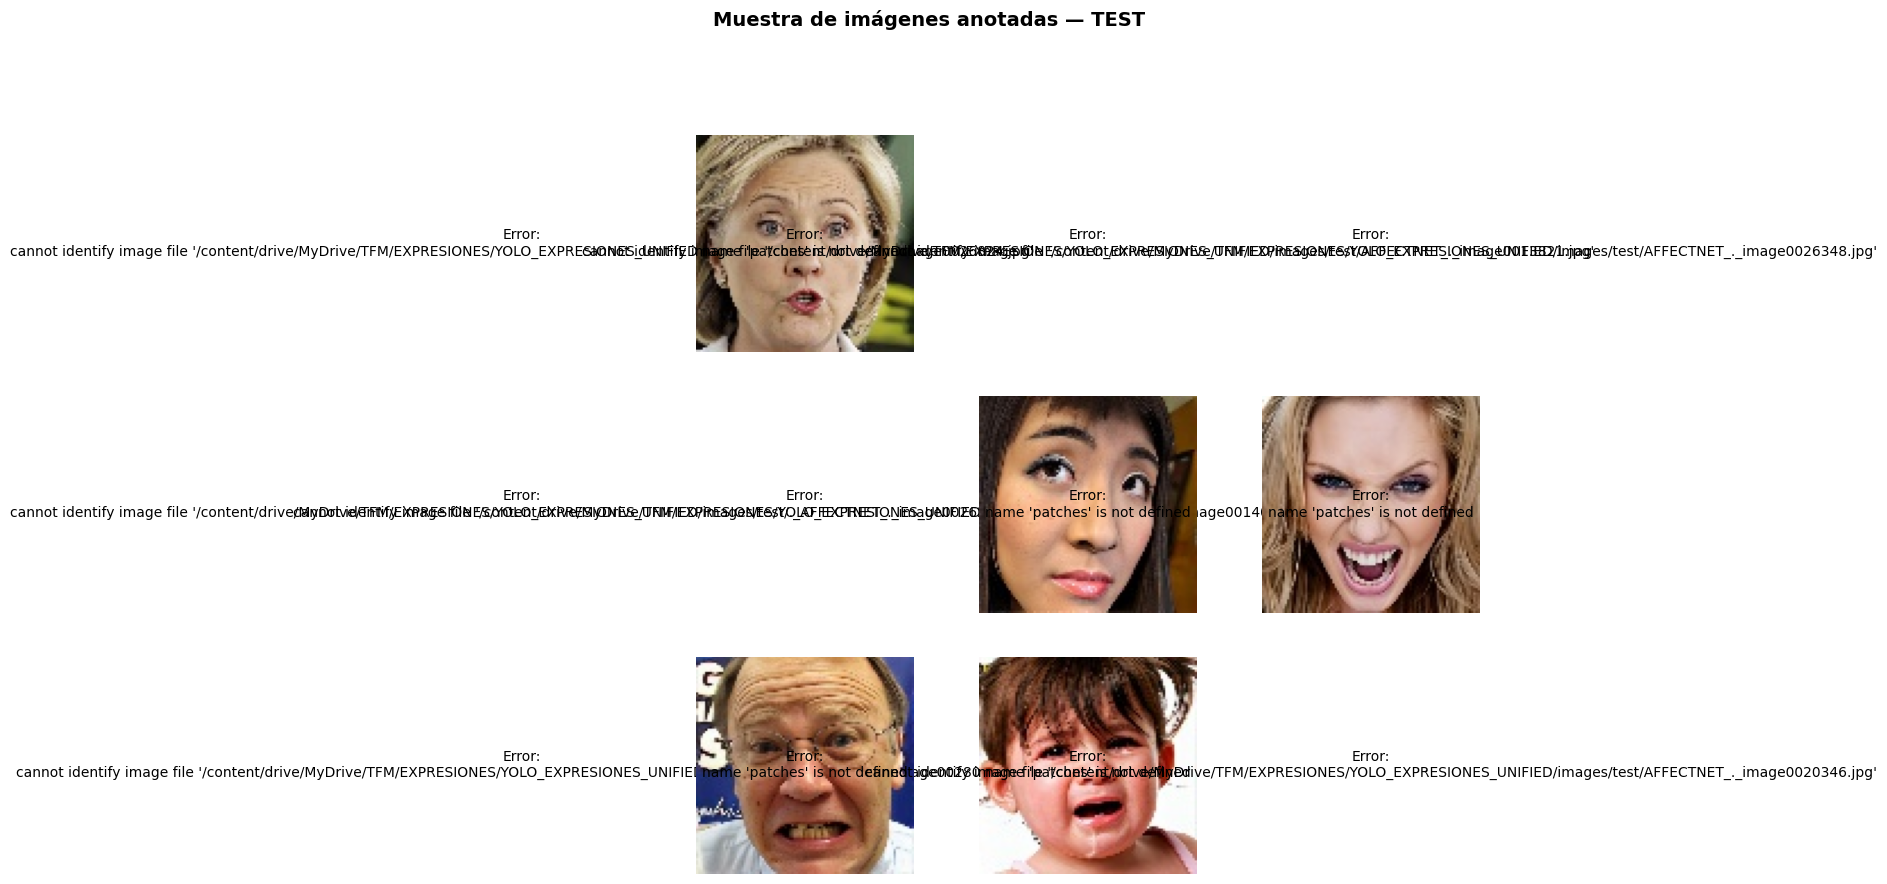

  📸 Guardado: /content/eda_muestra_test.png
  ✅ Visualización de muestras completada.


In [5]:
# ============================================================
# CELDA 8 – Muestra de imágenes con bounding boxes anotadas
# ============================================================
import random, math

PALETA_CLASES = plt.cm.get_cmap("tab10", NUM_CLASSES)

def dibujar_imagen_yolo(img_path, lbl_path, ax, class_names):
    """Dibuja imagen con sus bounding boxes en un eje matplotlib."""
    try:
        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        ax.imshow(img)
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cid  = int(parts[0])
                        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        x1 = (cx - bw/2) * W; y1 = (cy - bh/2) * H
                        pw = bw * W;           ph = bh * H
                        color = PALETA_CLASES(cid)
                        rect  = patches.Rectangle((x1, y1), pw, ph, linewidth=2,
                                                   edgecolor=color, facecolor='none')
                        ax.add_patch(rect)
                        lbl = class_names[cid] if cid < len(class_names) else str(cid)
                        ax.text(x1, y1 - 4, lbl, color='white', fontsize=7, fontweight='bold',
                                bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
        ax.axis('off')
        ax.set_title(img_path.name[:22], fontsize=7)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{e}", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

N_COLS = 4
N_ROWS = 3

for split in SPLITS:
    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split
    if not img_dir.exists():
        print(f"  ⚠️  {split}: carpeta no encontrada."); continue
    all_imgs = [p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
    if not all_imgs:
        print(f"  ⚠️  {split}: sin imágenes."); continue

    muestra = random.sample(all_imgs, min(N_COLS * N_ROWS, len(all_imgs)))
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS*3.5, N_ROWS*3.2))
    axes_flat = axes.flatten()
    for i, img_path in enumerate(muestra):
        dibujar_imagen_yolo(img_path, lbl_dir / (img_path.stem + ".txt"), axes_flat[i], CLASS_NAMES)
    for j in range(len(muestra), len(axes_flat)):
        axes_flat[j].axis('off')
    plt.suptitle(f"Muestra de imágenes anotadas — {split.upper()}", fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    out = f'/content/eda_muestra_{split}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
    print(f"  📸 Guardado: {out}")

print("  ✅ Visualización de muestras completada.")

# 📋 Sección 9 – Resumen Estadístico Final del Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 CONFIGURACIÓN
Ruta YOLO: /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
¿Existe?: True
images/train: True
labels/train: True
images/val  : True
labels/val  : True
images/test : True
labels/test : True

📋 RESUMEN EJECUTIVO DEL DATASET YOLO – EXPRESIONES FACIALES

📸 Total imágenes       : 29,880
🏷️ Total labels          : 29,880
📦 Total anotaciones     : 14,817
🎭 Clases               : 7 → ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

📊 Proporción de splits:
   TRAIN : █████████████████████████████████                   66.4%  (19,842 imgs)
   VAL   : ███████                                             15.7%  (4,685 imgs)
   TEST  : ████████                                            17.9%  (5,353 imgs)

🎭 DISTRIBUCIÓN DE EXPRESIONES VÁLIDAS POR SPLIT
split       test  train  val  total
class_name                       

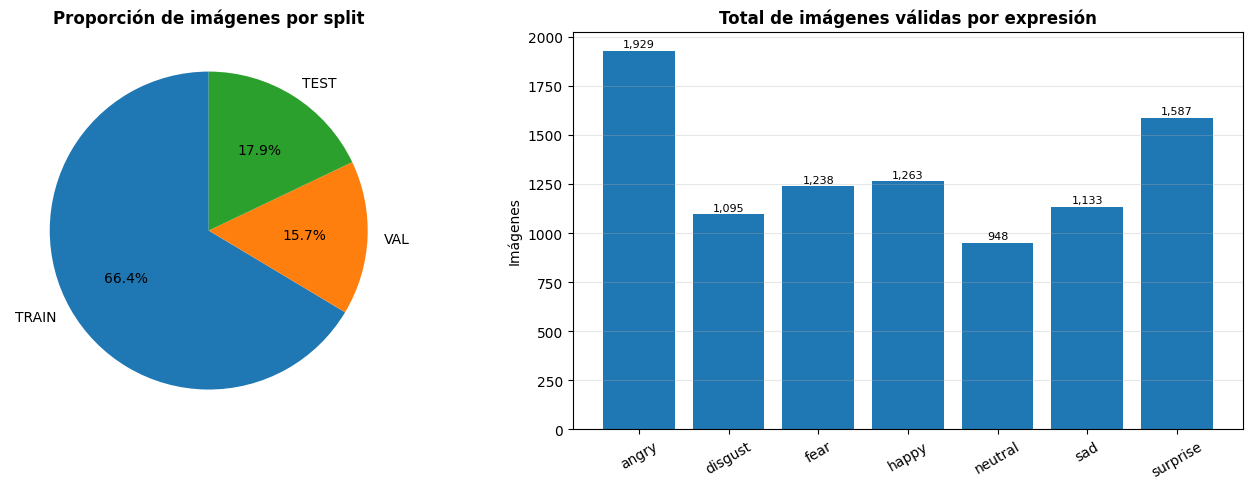


✅ EDA COMPLETADO
Archivos generados:
   • /content/eda_resumen_final_expresiones.png
   • /content/eda_resumen_clases_expresiones.csv
   • /content/eda_imagenes_expresiones.csv
   • /content/eda_bboxes_expresiones.csv
   • /content/eda_problemas_expresiones.csv

Interpretación para tu trabajo:

  - Esta celda resume el dataset como problema de expresiones faciales.
  - Cuenta imágenes válidas por clase, no solamente bounding boxes.
  - Si cada imagen tiene una caja de imagen completa, eso puede ser aceptable
    porque estás asociando una emoción a toda la imagen.
  - Lo más importante es que cada imagen tenga una sola clase válida:
        0 angry
        1 disgust
        2 fear
        3 happy
        4 neutral
        5 sad
        6 surprise



5

In [7]:
# ============================================================
# CELDA 9 – Resumen ejecutivo del EDA para EXPRESIONES FACIALES
#
# Versión autosuficiente:
#   - No depende de resumen_conteo
#   - No depende de dfs_bb
#   - No depende de resultados_imgs
#   - No depende de dist_clases
#
# Lee directamente desde:
#   /content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 0. Montar Google Drive
# ------------------------------------------------------------

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("ℹ️ Drive no se montó automáticamente. Si ya está montado, no hay problema.")


# ------------------------------------------------------------
# 1. Configuración del dataset
# ------------------------------------------------------------

YOLO = Path("/content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED")

SPLITS = ["train", "val", "test"]

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(CLASS_NAMES)

OUT_DIR = Path("/content")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("📁 CONFIGURACIÓN")
print("=" * 70)
print("Ruta YOLO:", YOLO)
print("¿Existe?:", YOLO.exists())

for split in SPLITS:
    print(f"images/{split:<5}:", (YOLO / "images" / split).exists())
    print(f"labels/{split:<5}:", (YOLO / "labels" / split).exists())


# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------

def listar_imagenes(img_dir):
    if not img_dir.exists():
        return []

    return sorted([
        p for p in img_dir.iterdir()
        if p.is_file() and p.suffix in IMG_EXTS
    ])


def listar_labels(lbl_dir):
    if not lbl_dir.exists():
        return []

    return sorted([
        p for p in lbl_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ])


def leer_label_yolo(label_path):
    """
    Lee un archivo YOLO:
        class_id cx cy w h

    Retorna una lista de registros válidos e inválidos.
    """
    registros = []

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as fh:
            for line_num, line in enumerate(fh, start=1):
                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                if len(parts) != 5:
                    registros.append({
                        "class_id": None,
                        "cx": None,
                        "cy": None,
                        "bw": None,
                        "bh": None,
                        "area": None,
                        "valida": False,
                        "motivo": "formato_incorrecto"
                    })
                    continue

                try:
                    class_id = int(float(parts[0]))
                    cx = float(parts[1])
                    cy = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])

                    clase_valida = 0 <= class_id < NUM_CLASSES
                    coords_validas = (
                        0 <= cx <= 1 and
                        0 <= cy <= 1 and
                        0 < bw <= 1 and
                        0 < bh <= 1
                    )

                    registros.append({
                        "class_id": class_id,
                        "cx": cx,
                        "cy": cy,
                        "bw": bw,
                        "bh": bh,
                        "area": bw * bh if bw > 0 and bh > 0 else None,
                        "valida": clase_valida and coords_validas,
                        "motivo": "ok" if clase_valida and coords_validas else "invalido"
                    })

                except Exception:
                    registros.append({
                        "class_id": None,
                        "cx": None,
                        "cy": None,
                        "bw": None,
                        "bh": None,
                        "area": None,
                        "valida": False,
                        "motivo": "valor_no_numerico"
                    })

    except Exception:
        registros.append({
            "class_id": None,
            "cx": None,
            "cy": None,
            "bw": None,
            "bh": None,
            "area": None,
            "valida": False,
            "motivo": "error_lectura"
        })

    return registros


def obtener_resolucion(img_path):
    try:
        with Image.open(img_path) as im:
            return im.size  # width, height
    except Exception:
        return None


# ------------------------------------------------------------
# 3. Lectura completa del dataset
# ------------------------------------------------------------

resumen_conteo = {}
dist_clases = {}
filas_bboxes = []
filas_imagenes = []
problemas = []

for split in SPLITS:
    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    imagenes = listar_imagenes(img_dir)
    labels = listar_labels(lbl_dir)

    imgs_stems = {p.stem for p in imagenes}
    lbls_stems = {p.stem for p in labels}

    sin_label = imgs_stems - lbls_stems
    sin_imagen = lbls_stems - imgs_stems
    coinciden = imgs_stems & lbls_stems

    resumen_conteo[split] = {
        "imagenes": len(imagenes),
        "labels": len(labels),
        "coincidencias": len(coinciden),
        "sin_label": len(sin_label),
        "sin_imagen": len(sin_imagen)
    }

    dist_clases[split] = {i: 0 for i in range(NUM_CLASSES)}

    # Resoluciones de imágenes
    for img_path in imagenes:
        res = obtener_resolucion(img_path)

        if res is None:
            problemas.append({
                "split": split,
                "stem": img_path.stem,
                "problema": "imagen_corrupta_o_no_leible"
            })
            continue

        w, h = res

        filas_imagenes.append({
            "split": split,
            "stem": img_path.stem,
            "width": w,
            "height": h,
            "resolucion": f"{w}×{h}"
        })

    # Labels y clases
    for lbl_path in labels:
        stem = lbl_path.stem

        if stem not in imgs_stems:
            problemas.append({
                "split": split,
                "stem": stem,
                "problema": "label_sin_imagen"
            })
            continue

        if lbl_path.stat().st_size == 0:
            problemas.append({
                "split": split,
                "stem": stem,
                "problema": "label_vacio"
            })
            continue

        registros = leer_label_yolo(lbl_path)
        validos = [r for r in registros if r["valida"]]

        if len(validos) == 0:
            problemas.append({
                "split": split,
                "stem": stem,
                "problema": "sin_label_valido"
            })
            continue

        clases_unicas = sorted(set(r["class_id"] for r in validos))

        if len(clases_unicas) > 1:
            problemas.append({
                "split": split,
                "stem": stem,
                "problema": "multiples_expresiones"
            })

        # Para tu caso, contamos la imagen si tiene una sola expresión válida
        if len(clases_unicas) == 1:
            dist_clases[split][clases_unicas[0]] += 1

        for r in registros:
            filas_bboxes.append({
                "split": split,
                "stem": stem,
                "class_id": r["class_id"],
                "class_name": CLASS_NAMES[r["class_id"]] if r["class_id"] is not None and 0 <= r["class_id"] < NUM_CLASSES else "INVALIDA",
                "cx": r["cx"],
                "cy": r["cy"],
                "bw": r["bw"],
                "bh": r["bh"],
                "area": r["area"],
                "valida": r["valida"],
                "motivo": r["motivo"]
            })

    for stem in sin_label:
        problemas.append({
            "split": split,
            "stem": stem,
            "problema": "imagen_sin_label"
        })

df_imgs = pd.DataFrame(filas_imagenes)
df_bboxes = pd.DataFrame(filas_bboxes)
df_problemas = pd.DataFrame(problemas)


# ------------------------------------------------------------
# 4. Resumen ejecutivo
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📋 RESUMEN EJECUTIVO DEL DATASET YOLO – EXPRESIONES FACIALES")
print("=" * 70)

total_imgs_global = sum(resumen_conteo[s]["imagenes"] for s in SPLITS)
total_lbls_global = sum(resumen_conteo[s]["labels"] for s in SPLITS)
total_bbs_global = len(df_bboxes)

print(f"\n📸 Total imágenes       : {total_imgs_global:,}")
print(f"🏷️ Total labels          : {total_lbls_global:,}")
print(f"📦 Total anotaciones     : {total_bbs_global:,}")
print(f"🎭 Clases               : {NUM_CLASSES} → {CLASS_NAMES}")

print("\n📊 Proporción de splits:")
for split in SPLITS:
    n = resumen_conteo[split]["imagenes"]
    pct = 100 * n / total_imgs_global if total_imgs_global > 0 else 0
    barra = "█" * int(pct / 2)
    print(f"   {split.upper():<6}: {barra:<50} {pct:5.1f}%  ({n:,} imgs)")


# ------------------------------------------------------------
# 5. Distribución de clases por split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🎭 DISTRIBUCIÓN DE EXPRESIONES VÁLIDAS POR SPLIT")
print("=" * 70)

filas_dist = []

for split in SPLITS:
    for cid, cname in enumerate(CLASS_NAMES):
        filas_dist.append({
            "split": split,
            "class_id": cid,
            "class_name": cname,
            "imagenes": dist_clases[split][cid]
        })

df_dist = pd.DataFrame(filas_dist)

tabla_dist = df_dist.pivot(
    index="class_name",
    columns="split",
    values="imagenes"
).fillna(0).astype(int)

tabla_dist = tabla_dist.reindex(CLASS_NAMES)
tabla_dist["total"] = tabla_dist.sum(axis=1)

print(tabla_dist.to_string())


# ------------------------------------------------------------
# 6. Desbalanceo en TRAIN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("⚖️ DESBALANCEO EN TRAIN")
print("=" * 70)

train_counts = np.array([dist_clases["train"][i] for i in range(NUM_CLASSES)])

if train_counts.sum() > 0:
    max_idx = int(train_counts.argmax())
    min_idx = int(train_counts.argmin())

    max_val = int(train_counts[max_idx])
    min_val = int(train_counts[min_idx])

    ratio = max_val / min_val if min_val > 0 else float("inf")

    for i, count in enumerate(train_counts):
        pct = 100 * count / train_counts.sum()
        print(f"   {CLASS_NAMES[i]:<14}: {count:>7,}  ({pct:5.1f}%)")

    print(f"\nRatio max/min: {ratio:.2f}x")
    print(f"Mayor clase  : {CLASS_NAMES[max_idx]} ({max_val:,})")
    print(f"Menor clase  : {CLASS_NAMES[min_idx]} ({min_val:,})")

    if ratio > 3:
        print("⚠️ Desbalanceo alto. Conviene usar aumento de datos, oversampling o pesos por clase.")
    elif ratio > 1.8:
        print("⚠️ Desbalanceo moderado. Puede ser aceptable, pero conviene vigilar métricas por clase.")
    else:
        print("✅ Dataset relativamente balanceado.")
else:
    print("⚠️ No se encontraron clases válidas en TRAIN.")


# ------------------------------------------------------------
# 7. Resolución más frecuente
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📐 RESOLUCIONES")
print("=" * 70)

if not df_imgs.empty:
    df_train_imgs = df_imgs[df_imgs["split"] == "train"]

    if not df_train_imgs.empty:
        resols_train = Counter(df_train_imgs["resolucion"])
        top1_res = resols_train.most_common(1)[0]

        print(f"Resolución más frecuente en train: {top1_res[0]} ({top1_res[1]:,} imgs)")

        if len(resols_train) == 1:
            print("✅ Todas las imágenes de train tienen la misma resolución.")
        else:
            print(f"⚠️ Hay {len(resols_train)} resoluciones distintas en train.")
            print("YOLO las redimensionará durante el entrenamiento.")

        print("\nTop 10 resoluciones:")
        for res, n in resols_train.most_common(10):
            print(f"   {res:<12} {n:,}")
else:
    print("⚠️ No se pudieron leer resoluciones de imágenes.")


# ------------------------------------------------------------
# 8. Análisis simple de bounding boxes como imagen completa
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📦 BOUNDING BOXES COMO IMAGEN COMPLETA")
print("=" * 70)

if not df_bboxes.empty:
    df_valid = df_bboxes[df_bboxes["valida"] == True].copy()

    if not df_valid.empty:
        df_valid["bbox_full_img"] = (
            (df_valid["cx"].between(0.45, 0.55)) &
            (df_valid["cy"].between(0.45, 0.55)) &
            (df_valid["bw"] >= 0.90) &
            (df_valid["bh"] >= 0.90)
        )

        pct_full = 100 * df_valid["bbox_full_img"].mean()
        area_media = df_valid["area"].mean()
        area_mediana = df_valid["area"].median()

        print(f"Área media bbox       : {area_media:.4f}")
        print(f"Área mediana bbox     : {area_mediana:.4f}")
        print(f"BBoxes imagen completa: {pct_full:.2f}%")

        if pct_full > 80:
            print("✅ Compatible con tu enfoque: expresión asignada a la imagen completa.")
        else:
            print("⚠️ Hay muchas cajas parciales. Revisa si representan correctamente el rostro.")
else:
    print("⚠️ No se encontraron anotaciones YOLO.")


# ------------------------------------------------------------
# 9. Exportar CSVs
# ------------------------------------------------------------

csv_clases = OUT_DIR / "eda_resumen_clases_expresiones.csv"
csv_problemas = OUT_DIR / "eda_problemas_expresiones.csv"
csv_bboxes = OUT_DIR / "eda_bboxes_expresiones.csv"
csv_imgs = OUT_DIR / "eda_imagenes_expresiones.csv"

df_dist.to_csv(csv_clases, index=False)
df_imgs.to_csv(csv_imgs, index=False)

if not df_bboxes.empty:
    df_bboxes.to_csv(csv_bboxes, index=False)

if not df_problemas.empty:
    df_problemas.to_csv(csv_problemas, index=False)

print("\n" + "=" * 70)
print("💾 CSV EXPORTADOS")
print("=" * 70)
print(f"Clases     : {csv_clases}")
print(f"Imágenes   : {csv_imgs}")

if not df_bboxes.empty:
    print(f"BBoxes     : {csv_bboxes}")

if not df_problemas.empty:
    print(f"Problemas  : {csv_problemas}")
else:
    print("Problemas  : no se encontraron problemas estructurales.")


# ------------------------------------------------------------
# 10. Gráfica final: proporción splits + clases
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vals_splits = [resumen_conteo[s]["imagenes"] for s in SPLITS]

axes[0].pie(
    vals_splits,
    labels=[s.upper() for s in SPLITS],
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title("Proporción de imágenes por split", fontweight="bold")

total_por_clase = [
    sum(dist_clases[s][i] for s in SPLITS)
    for i in range(NUM_CLASSES)
]

bars = axes[1].bar(CLASS_NAMES, total_por_clase)

axes[1].set_title("Total de imágenes válidas por expresión", fontweight="bold")
axes[1].set_ylabel("Imágenes")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

max_val = max(total_por_clase) if total_por_clase else 0

for bar, v in zip(bars, total_por_clase):
    if v > 0:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_val * 0.01,
            f"{v:,}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()

fig_path = OUT_DIR / "eda_resumen_final_expresiones.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 11. Diagnóstico final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ EDA COMPLETADO")
print("=" * 70)

print("Archivos generados:")
print(f"   • {fig_path}")
print(f"   • {csv_clases}")
print(f"   • {csv_imgs}")

if not df_bboxes.empty:
    print(f"   • {csv_bboxes}")

if not df_problemas.empty:
    print(f"   • {csv_problemas}")

print("""
Interpretación para tu trabajo:

  - Esta celda resume el dataset como problema de expresiones faciales.
  - Cuenta imágenes válidas por clase, no solamente bounding boxes.
  - Si cada imagen tiene una caja de imagen completa, eso puede ser aceptable
    porque estás asociando una emoción a toda la imagen.
  - Lo más importante es que cada imagen tenga una sola clase válida:
        0 angry
        1 disgust
        2 fear
        3 happy
        4 neutral
        5 sad
        6 surprise
""")

gc.collect()

In [8]:
# ============================================================
# VERIFICACIÓN FINAL ANTES DE ENTRENAR
# ============================================================

from pathlib import Path
from collections import Counter
import pandas as pd

YOLO = Path("/content/drive/MyDrive/TFM/EXPRESIONES/YOLO_EXPRESIONES_UNIFIED")

SPLITS = ["train", "val", "test"]

CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

def contar_imgs(split):
    img_dir = YOLO / "images" / split
    return [
        p for p in img_dir.iterdir()
        if p.is_file() and p.suffix in IMG_EXTS
    ]

def leer_clase_label(lbl_path):
    clases = []
    try:
        with open(lbl_path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) == 5:
                    cid = int(float(parts[0]))
                    if 0 <= cid < len(CLASS_NAMES):
                        clases.append(cid)
    except Exception:
        pass
    return sorted(set(clases))

print("=" * 70)
print("🔎 VERIFICACIÓN FINAL ANTES DE ENTRENAR")
print("=" * 70)

total_imgs = 0
conteo_split = {}

for split in SPLITS:
    imgs = contar_imgs(split)
    conteo_split[split] = len(imgs)
    total_imgs += len(imgs)

print("\n📊 Proporción real por split:")
for split in SPLITS:
    pct = 100 * conteo_split[split] / total_imgs if total_imgs > 0 else 0
    print(f"  {split.upper():<6}: {conteo_split[split]:>6,} imágenes  ({pct:5.1f}%)")

print("\n🎭 Distribución por clase:")
for split in SPLITS:
    lbl_dir = YOLO / "labels" / split
    counter = Counter()

    for lbl_path in lbl_dir.glob("*.txt"):
        clases = leer_clase_label(lbl_path)

        if len(clases) == 1:
            counter[clases[0]] += 1

    print(f"\n{split.upper()}")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name:<10}: {counter[i]:>6,}")

print("\n🧪 Verificando aumentaciones fuera de TRAIN:")

for split in ["val", "test"]:
    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    imgs_aug = list(img_dir.glob("aug_*")) if img_dir.exists() else []
    lbls_aug = list(lbl_dir.glob("aug_*")) if lbl_dir.exists() else []

    print(f"  {split.upper()}: aug images={len(imgs_aug):,}, aug labels={len(lbls_aug):,}")

    if len(imgs_aug) > 0 or len(lbls_aug) > 0:
        print(f"  ⚠️ Atención: hay aumentaciones en {split.upper()}. No recomendado.")

print("\n✅ Verificación final completada.")

🔎 VERIFICACIÓN FINAL ANTES DE ENTRENAR

📊 Proporción real por split:
  TRAIN : 19,842 imágenes  ( 66.4%)
  VAL   :  4,685 imágenes  ( 15.7%)
  TEST  :  5,353 imágenes  ( 17.9%)

🎭 Distribución por clase:

TRAIN
  angry     :  1,047
  disgust   :    889
  fear      :    889
  happy     :    889
  neutral   :    889
  sad       :    889
  surprise  :    897

VAL
  angry     :    390
  disgust   :    102
  fear      :    176
  happy     :    170
  neutral   :     27
  sad       :    107
  surprise  :    323

TEST
  angry     :    492
  disgust   :    104
  fear      :    173
  happy     :    204
  neutral   :     32
  sad       :    137
  surprise  :    367

🧪 Verificando aumentaciones fuera de TRAIN:
  VAL: aug images=0, aug labels=0
  TEST: aug images=0, aug labels=0

✅ Verificación final completada.
